![](https://noticias.maisesports.com.br/wp-content/uploads/2016/06/CSGO.png)

# What is CS:GO?

If you have never heard of one games industry titans, it is probably you have being living under a rock for the past two decades or so. CS:GO predecessors, each in its own right, are marble of your age, from [CS 1.6](https://en.wikipedia.org/wiki/Counter-Strike_(video_game)) earlier days as a Half Life mod, to its present form as a eSport behemoth, CS is undoubtedly one of games industry beacons of popularity. But what is CS?

Counter-Strike (CS) is a series of multiplayer first-person shooter video games in which teams of terrorists battle to perpetrate an act of terror (bombing, hostage-taking, assassination) while counter-terrorists try to prevent it (bomb defusal, hostage rescue), [[source]](https://en.wikipedia.org/wiki/Counter-Strike:_Global_Offensive). This is the factual description, but for its players it's a game that encorages high level strategies and bring back memories of fun times with friends at LAN parties, even if that is enfuriating some times.

With that in mind this Kernel graphically analyzes the data of ~700 matchs of high level play.

In [1]:
options(warn=-1)
library(tidyverse) # metapackage of all tidyverse packages
library(ggrepel)
library(ggridges)
library(cowplot)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.0 ──

✔ ggplot2 3.3.2.9000     ✔ purrr   0.3.4     
✔ tibble  3.0.3          ✔ dplyr   1.0.1     
✔ tidyr   1.1.1          ✔ stringr 1.4.0     
✔ readr   1.3.1          ✔ forcats 0.5.0     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


********************************************************

Note: As of version 1.0.0, cowplot does not change the

  default ggplot2 theme anymore. To recover the previous

  behavior, execute:
  theme_set(theme_cowplot())

********************************************************




In [2]:
dt <- read_csv('../input/csgo-round-winner-classification/csgo_round_snapshots.csv',
               col_types = cols(.default=col_double(),
                                map = col_character(),
                                bomb_planted = col_logical(),
                               round_winner = col_character()))

In [3]:
dt <- dt %>% drop_na() # drop that single NA
head(dt)

time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,⋯,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner
<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
175.00,0,0,de_dust2,FALSE,500,500,0,0,4000,⋯,0,0,0,0,0,0,0,0,0,CT
156.03,0,0,de_dust2,FALSE,500,500,400,300,600,⋯,0,0,2,0,0,0,0,0,0,CT
96.03,0,0,de_dust2,FALSE,391,400,294,200,750,⋯,0,0,2,0,0,0,0,0,0,CT
76.03,0,0,de_dust2,FALSE,391,400,294,200,750,⋯,0,0,0,0,0,0,0,0,0,CT
174.97,1,0,de_dust2,FALSE,500,500,192,0,18350,⋯,0,0,0,0,0,0,0,0,0,CT
114.97,1,0,de_dust2,FALSE,500,500,500,0,1750,⋯,0,3,0,1,0,0,0,0,0,CT


# Data Wrangling

In the current state of the data its hard to make meaningful visualizations, since there is no distinction between matchs, rounds and a standard timestamp across all instances.

### Match Id column

The first line checks if the previous row(lag function) is equal to current row, if true it assigns NoID to that row, otherwise it assigns the current row_number(). The subsequence line fixes a issue with the first row and then foward feeds the match_id column.

In [4]:
dt <- dt %>%
    mutate(match_id=ifelse(lag(map)==map,'NoID',row_number())) %>%
    mutate(match_id=ifelse(is.na(match_id),row_number(),match_id)) %>%
    mutate(match_id=ifelse(match_id=='NoID',NA,match_id)) %>%
    fill(match_id) %>% # foward fill
    mutate(match_id=paste('ID:',match_id))

### Round column

Create a round column that indicates in which round are we in.

In [5]:
dt <- dt %>% 
    group_by(match_id,t_score,ct_score) %>%
    mutate(round = ct_score + t_score + 1) %>%
    ungroup() 

dt %>% select(ct_score,t_score,round) %>% head(20)

ct_score,t_score,round
<dbl>,<dbl>,<dbl>
0,0,1
0,0,1
0,0,1
0,0,1
1,0,2
1,0,2
1,0,2
1,0,2
1,0,2


### Fixing the time_left column

In [6]:
sort(unique(dt$time_left))

[1]   0.01   0.02   0.03   0.04   0.05   0.06   0.07   0.08   0.09   0.10
   [11]   0.11   0.12   0.14   0.15   0.16   0.18   0.19   0.20   0.21   0.22
   [21]   0.23   0.24   0.25   0.26   0.27   0.28   0.29   0.30   0.32   0.33
   [31]   0.34   0.35   0.36   0.37   0.38   0.40   0.41   0.43   0.44   0.45
   [41]   0.48   0.49   0.50   0.51   0.52   0.55   0.57   0.58   0.59   0.60
   [51]   0.61   0.62   0.63   0.64   0.65   0.66   0.67   0.69   0.70   0.71
   [61]   0.72   0.73   0.75   0.76   0.77   0.78   0.79   0.80   0.81   0.82
   [71]   0.83   0.84   0.85   0.87   0.88   0.89   0.90   0.91   0.93   0.94
   [81]   0.95   0.97   0.98   0.99   1.00   1.01   1.02   1.03   1.05   1.08
   [91]   1.09   1.10   1.11   1.12   1.13   1.16   1.18   1.19   1.20   1.21
  [101]   1.23   1.24   1.25   1.26   1.28   1.29   1.30   1.31   1.32   1.33
  [111]   1.34   1.35   1.36   1.37   1.38   1.39   1.40   1.41   1.42   1.45
  [121]   1.46   1.47   1.48   1.49   1.50   1.51   1.52   1.53   1.54   1.55
  [131]   1.56   1.57   1.58   1.59   1.60   1.61   1.62   1.64   1.65   1.66
  [141]   1.67   1.68   1.69   1.71   1.72   1.73   1.76   1.77   1.78   1.79
  [151]   1.81   1.82   1.84   1.85   1.86   1.87   1.88   1.89   1.90   1.91
  [161]   1.93   1.94   1.95   1.96   1.97   1.98   1.99   2.00   2.01   2.02
  [171]   2.03   2.04   2.05   2.06   2.07   2.09   2.10   2.11   2.12   2.13
  [181]   2.14   2.15   2.16   2.17   2.19   2.20   2.22   2.23   2.24   2.25
  [191]   2.26   2.28   2.29   2.30   2.31   2.32   2.33   2.34   2.35   2.36
  [201]   2.37   2.38   2.39   2.41   2.42   2.43   2.45   2.48   2.49   2.50
  [211]   2.51   2.52   2.53   2.55   2.57   2.61   2.65   2.66   2.67   2.69
  [221]   2.70   2.73   2.75   2.76   2.77   2.78   2.79   2.80   2.81   2.82
  [231]   2.83   2.84   2.85   2.87   2.88   2.89   2.90   2.91   2.92   2.94
  [241]   2.95   2.98   2.99   3.00   3.01   3.02   3.03   3.04   3.05   3.06
  [251]   3.07   3.09   3.12   3.13   3.14   3.17   3.18   3.19   3.20   3.21
  [261]   3.22   3.23   3.25   3.27   3.28   3.29   3.30   3.31   3.32   3.33
  [271]   3.34   3.35   3.36   3.37   3.38   3.39   3.40   3.41   3.42   3.43
  [281]   3.44   3.45   3.46   3.47   3.48   3.49   3.50   3.51   3.52   3.53
  [291]   3.54   3.55   3.56   3.57   3.59   3.61   3.62   3.63   3.64   3.65
  [301]   3.66   3.67   3.68   3.69   3.70   3.71   3.73   3.75   3.77   3.78
  [311]   3.79   3.80   3.81   3.82   3.83   3.84   3.85   3.86   3.88   3.90
  [321]   3.91   3.92   3.93   3.94   3.95   3.96   3.97   3.98   4.00   4.01
  [331]   4.02   4.03   4.04   4.05   4.06   4.07   4.08   4.09   4.10   4.11
  [341]   4.12   4.13   4.14   4.15   4.16   4.17   4.19   4.20   4.21   4.22
  [351]   4.23   4.26   4.27   4.28   4.29   4.30   4.31   4.32   4.34   4.35
  [361]   4.36   4.37   4.38   4.39   4.40   4.41   4.42   4.43   4.45   4.47
  [371]   4.48   4.49   4.51   4.52   4.53   4.54   4.55   4.57   4.58   4.59
  [381]   4.60   4.61   4.62   4.64   4.65   4.66   4.67   4.68   4.69   4.70
  [391]   4.71   4.72   4.73   4.74   4.75   4.76   4.77   4.78   4.79   4.80
  [401]   4.81   4.83   4.84   4.85   4.86   4.87   4.88   4.89   4.90   4.91
  [411]   4.92   4.93   4.94   4.95   4.96   4.98   4.99   5.00   5.01   5.02
  [421]   5.03   5.04   5.05   5.06   5.07   5.08   5.09   5.10   5.11   5.12
  [431]   5.13   5.14   5.15   5.16   5.18   5.19   5.20   5.21   5.22   5.23
  [441]   5.24   5.25   5.26   5.27   5.28   5.29   5.30   5.31   5.33   5.34
  [451]   5.35   5.36   5.37   5.38   5.39   5.40   5.41   5.42   5.43   5.44
  [461]   5.45   5.46   5.47   5.48   5.50   5.51   5.52   5.53   5.54   5.55
  [471]   5.56   5.57   5.59   5.60   5.61   5.62   5.63   5.64   5.65   5.66
  [481]   5.67   5.68   5.69   5.70   5.71   5.72   5.73   5.74   5.75   5.76
  [491]   5.77   5.78   5.80   5.81   5.82   5.83   5.84   5.87   5.88   5.89
  [501]   5.90   5.91   5.92   5.94   5.95   5.96   5.97   5.98   5.99   6.00
  [511]   6.01   6.02   6.

As it can be seen the time_left has a wide range of values, as opposed to ordered timestamps. In order to fix this issue the timestamps with be rounded and then divided in intervals of 7 seconds each.

**Disclamer**, in the case of duplicated rows they will be dropped as a means to prevent redundant data points in the comming visualizations.

In [7]:
dt <- dt %>% mutate(time_left = round(time_left)) %>%
    mutate(time_left = ifelse(time_left<=25,25,time_left)) %>%
    mutate(time_left = ifelse(25 < time_left &  time_left <= 50, 50,time_left)) %>%
    mutate(time_left = ifelse(50 < time_left &  time_left <= 75, 75,time_left)) %>%
    mutate(time_left = ifelse(75 < time_left &  time_left <= 100, 100,time_left)) %>%
    mutate(time_left = ifelse(100 < time_left &  time_left <= 125, 125,time_left)) %>%
    mutate(time_left = ifelse(125 < time_left &  time_left <= 150, 150,time_left)) %>%
    mutate(time_left = ifelse(150 < time_left &  time_left <= 175, 175,time_left)) %>%
    group_by(match_id,round) %>%
    distinct(time_left,.keep_all = TRUE) %>% ungroup()

# Exploratory Data Analysis

In [8]:
options(repr.plot.width = 15, repr.plot.height = 7.5)
text = element_text(size=14, face="bold")
standard_theme <-  theme_minimal() + theme(axis.text.x = text ,axis.text.y = text,
                                           axis.title.x = text,axis.title.y = text,
                                           legend.title = element_text(size=16, face="bold"),
                                           legend.text = text,
                                           plot.title = text)
#color pallete
ctr_fill = scale_fill_manual(values = c('#084d6e','#9b902c'))

### Is there a map side advantage ?

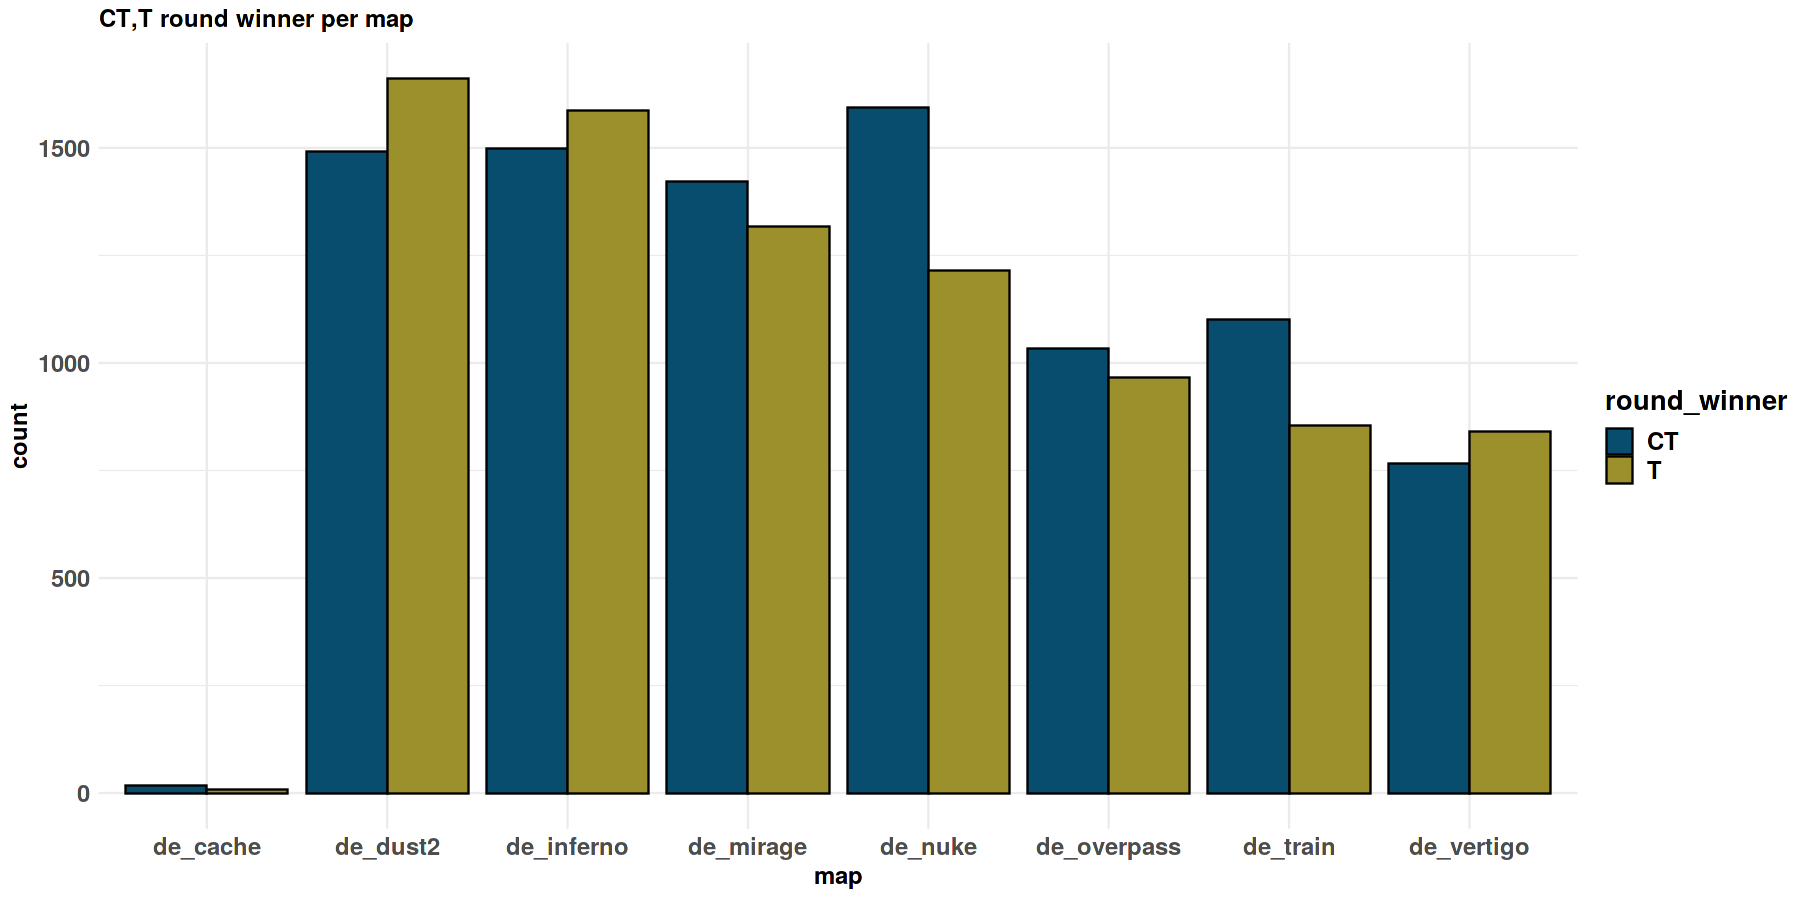

In [9]:
dt %>% group_by(match_id) %>% distinct(ct_score,t_score,.keep_all=TRUE) %>% # preventing double counting
    ungroup() %>% ggplot(aes(x=map,fill=round_winner)) +
    geom_bar(position = "dodge",color='black') +
    ctr_fill +
    ggtitle('CT,T round winner per map') +
    standard_theme

No surprises there about de_dust2 popularity and T side apparent advantage. On the other hand de_nuke appers to be more CT side orientated.

### What are the most common weapons and grenades on both sides ?

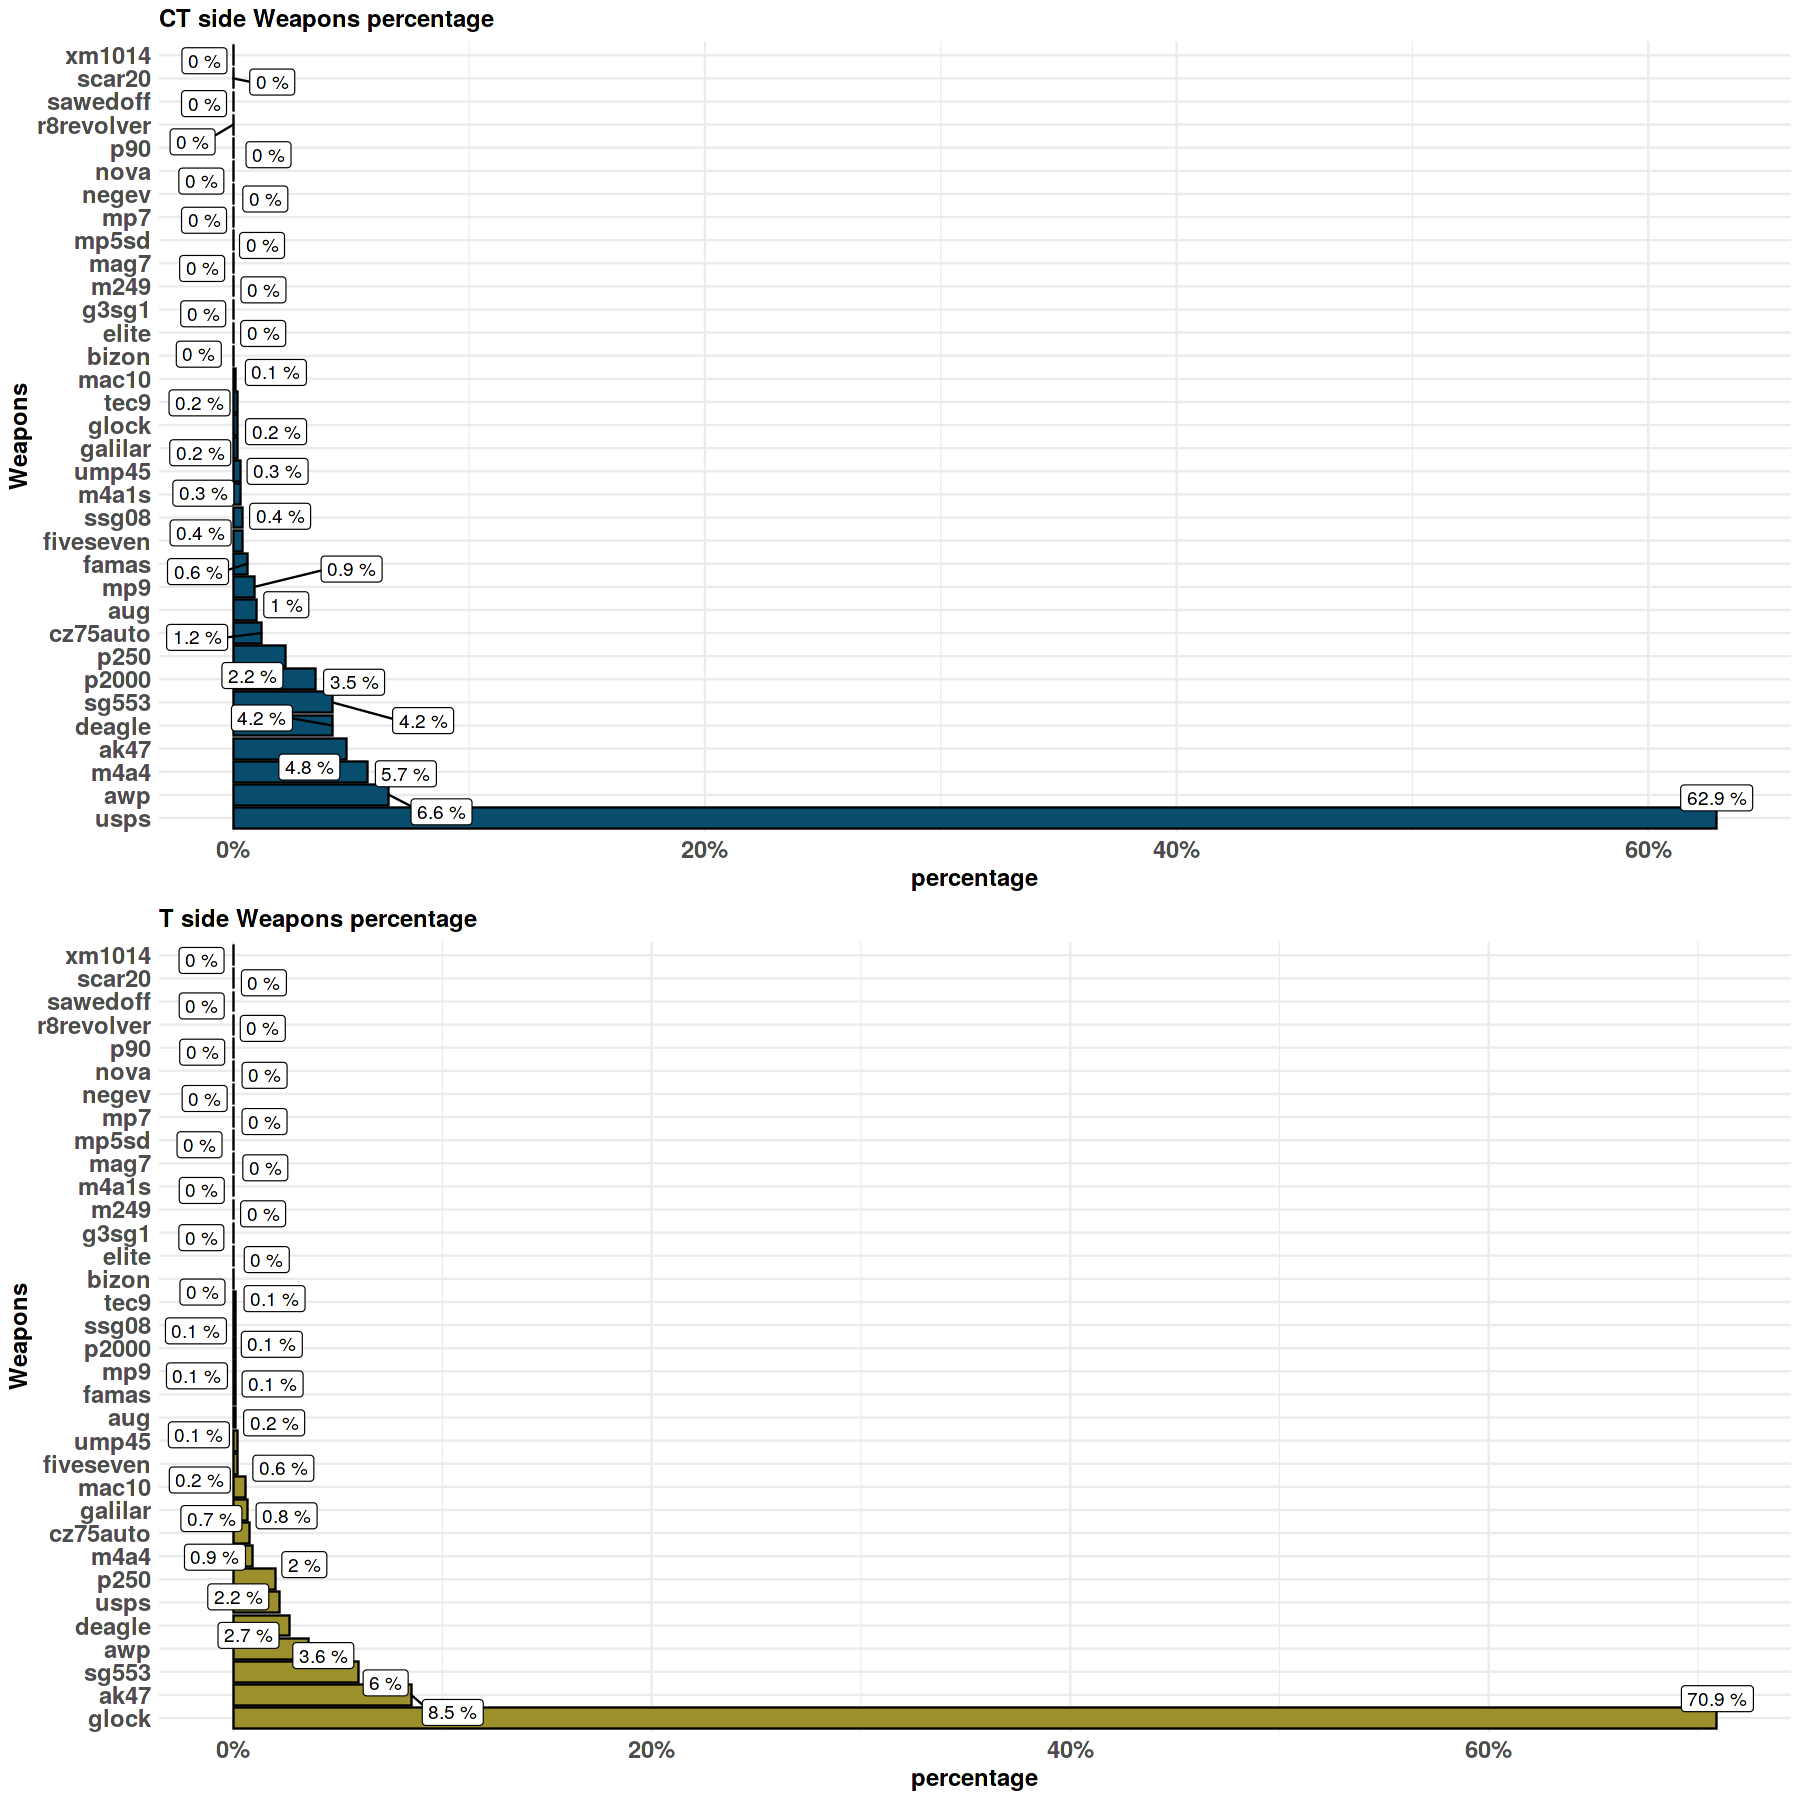

In [10]:
options(repr.plot.height = 15)
# simple function for plot similar graphics
weapon_plot <- function(column,title,fill,ylab){
    p = dt %>% group_by(match_id) %>% distinct(ct_score,t_score,.keep_all=TRUE) %>% 
    ungroup() %>% select(starts_with(column)) %>%
    gather(key=weapons,value=amount) %>%
    group_by(weapons) %>% mutate(amount = sum(amount)) %>% 
    ungroup() %>% unique() %>%
    mutate(percentage = round(amount / sum(amount),3)) %>%
    mutate(weapons = str_replace(weapons,column,'')) %>%
    ggplot(aes(y = reorder(weapons, -percentage),x = percentage)) +
    geom_col(color='black',fill=fill) + 
    geom_label_repel(aes(label = paste((percentage)*100,'%')))+
    scale_x_continuous(labels = scales::percent) +
    ggtitle(title)+
    ylab(ylab)+
    standard_theme
    
    return(p)
    
}

t_weapons = weapon_plot(column='t_weapon_',title='T side Weapons percentage',
                        fill='#9b902c',ylab='Weapons')

ct_weapons = weapon_plot(column='ct_weapon_',title='CT side Weapons percentage',
                        fill='#084d6e',ylab='Weapons')

plot_grid(plotlist=list(ct_weapons,t_weapons),ncol=1,nrow=2)

Even though glock and usps are pistols, they are mostly used in echo rounds -- rounds that the players lacks money to buy primary equipment -- and in starting rounds. Therefore a graph excluding this side arms should be made.

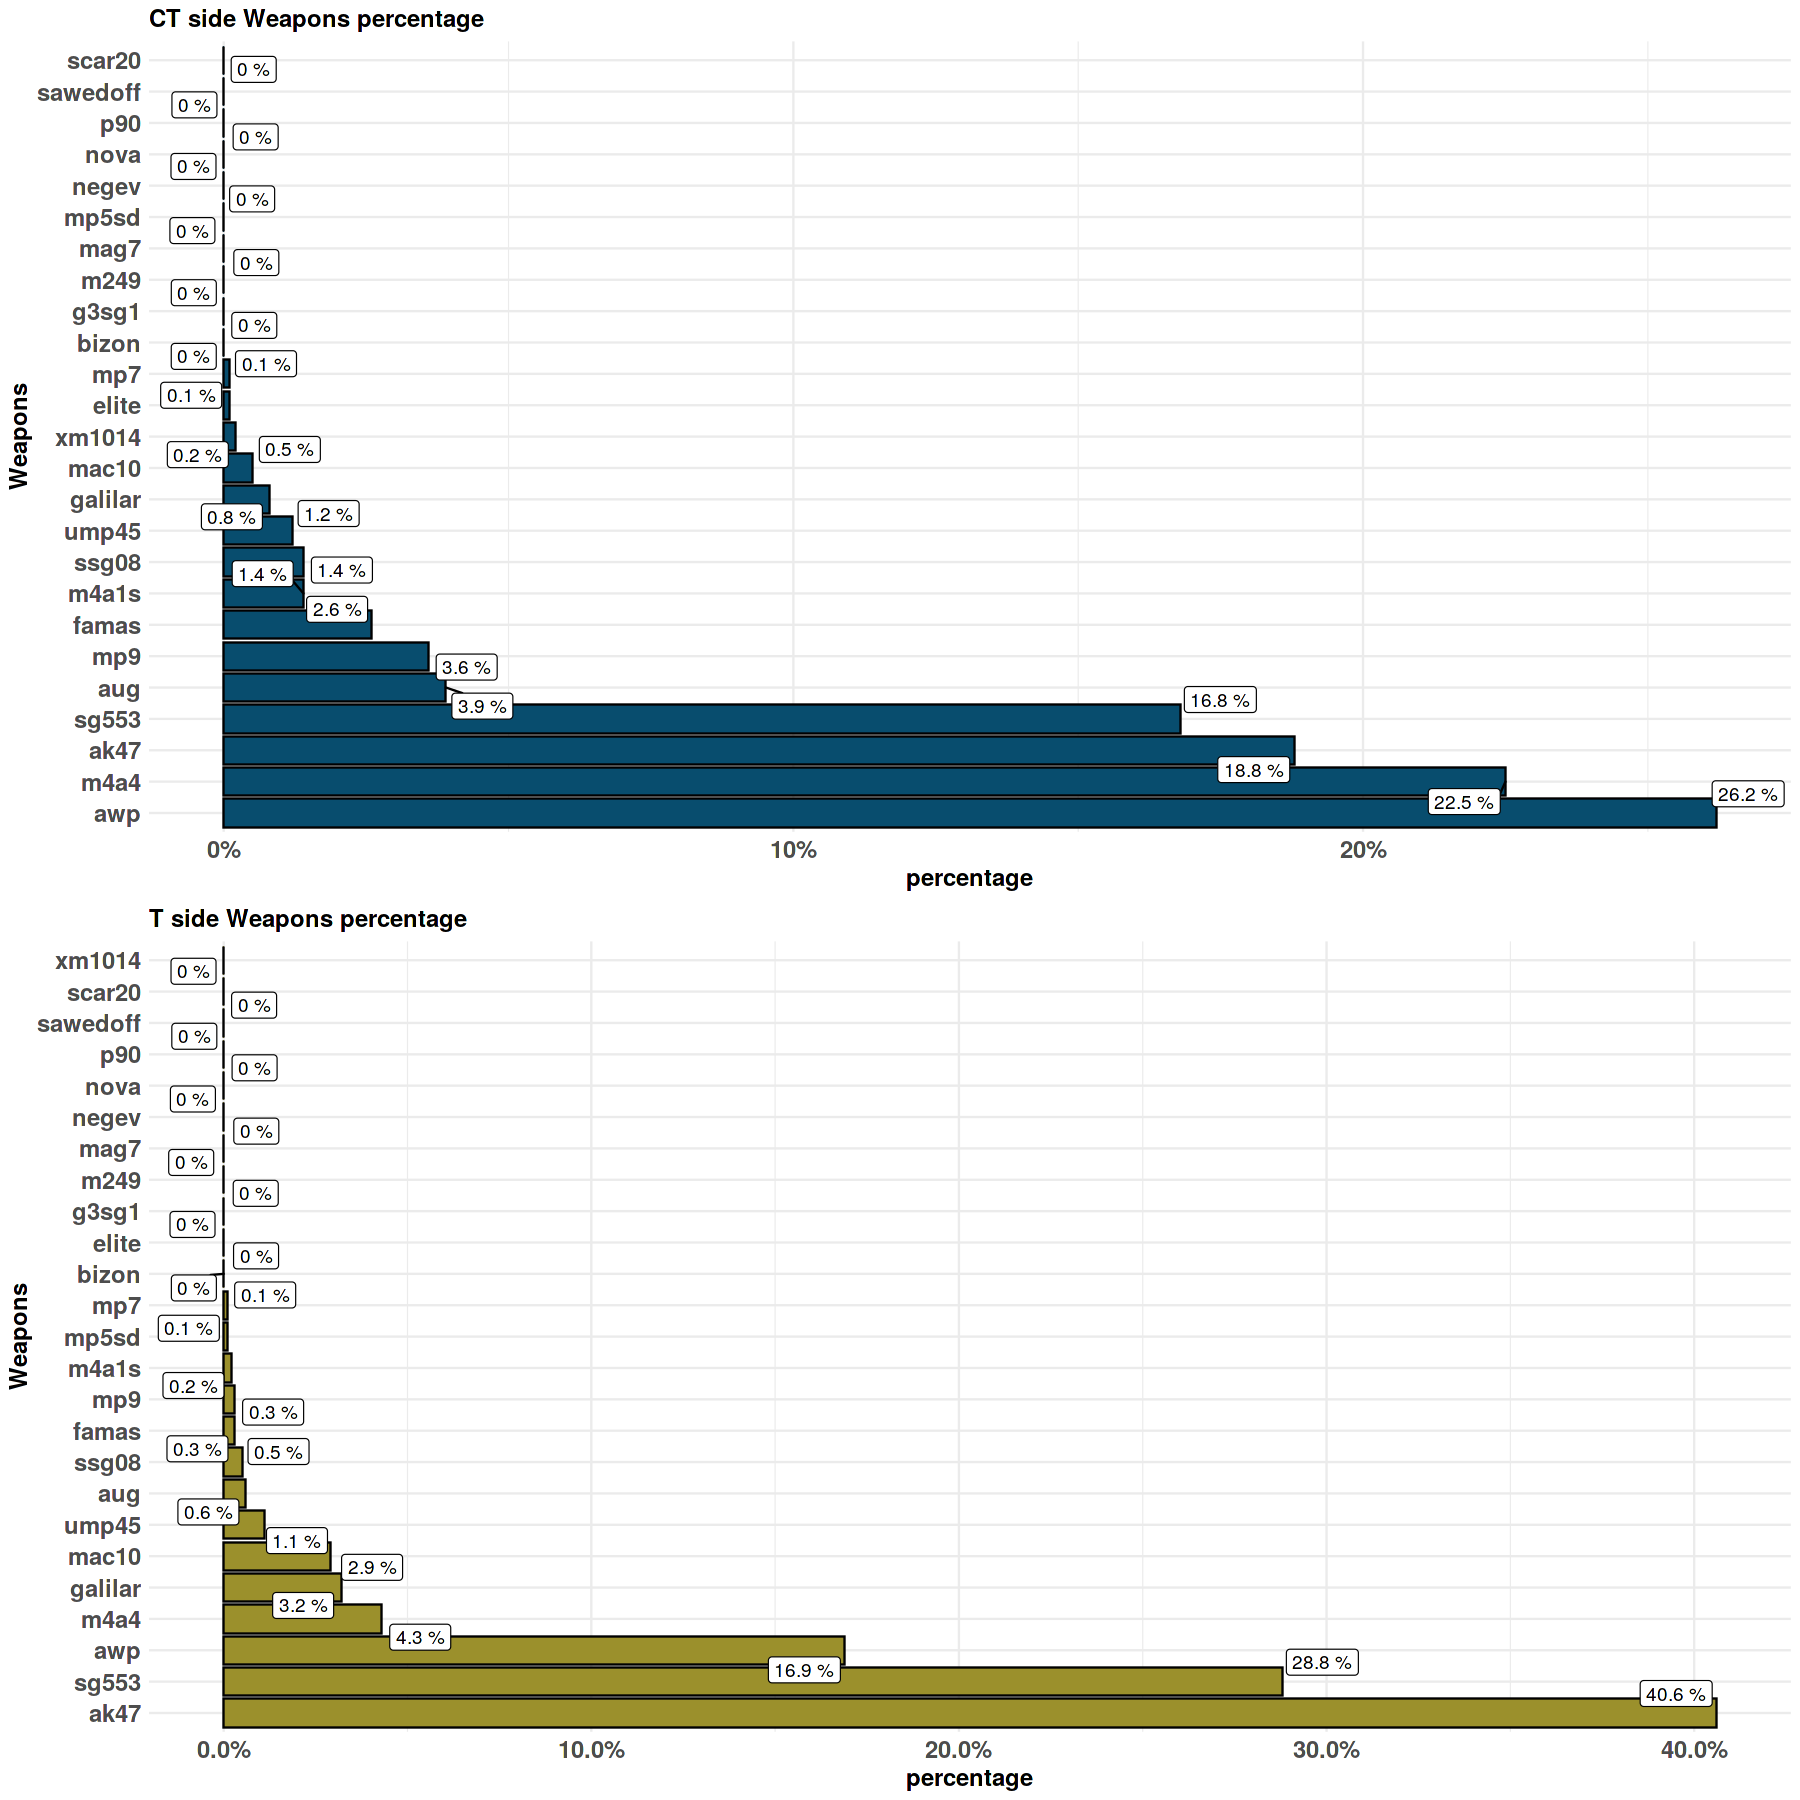

In [11]:
pistols = c('glock','p2000','usps','p250','tec9','fiveseven','cz75auto','deagle','r8revolver')

weapon_plot_filter <- function(column,title,fill,ylab){
    p = dt %>% group_by(match_id) %>% distinct(ct_score,t_score,.keep_all=TRUE) %>% 
    ungroup() %>% select(starts_with(column)) %>%
    gather(key=weapons,value=amount) %>%
    group_by(weapons) %>% mutate(amount = sum(amount)) %>% 
    ungroup() %>% unique() %>%
    mutate(weapons = str_replace(weapons,column,'')) %>%
    filter(!(weapons %in% pistols)) %>%
    mutate(percentage = round(amount / sum(amount),3)) %>%
    ggplot(aes(y = reorder(weapons, -percentage),x = percentage)) +
    geom_col(color='black',fill=fill) + 
    geom_label_repel(aes(label = paste((percentage)*100,'%')))+
    scale_x_continuous(labels = scales::percent) +
    ggtitle(title)+
    ylab(ylab)+
    standard_theme
    
    return(p)
    
}

t_weapons = weapon_plot_filter(column='t_weapon_',title='T side Weapons percentage',
                        fill='#9b902c',ylab='Weapons')

ct_weapons = weapon_plot_filter(column='ct_weapon_',title='CT side Weapons percentage',
                        fill='#084d6e',ylab='Weapons')


plot_grid(plotlist=list(ct_weapons,t_weapons),ncol=1,nrow=2)

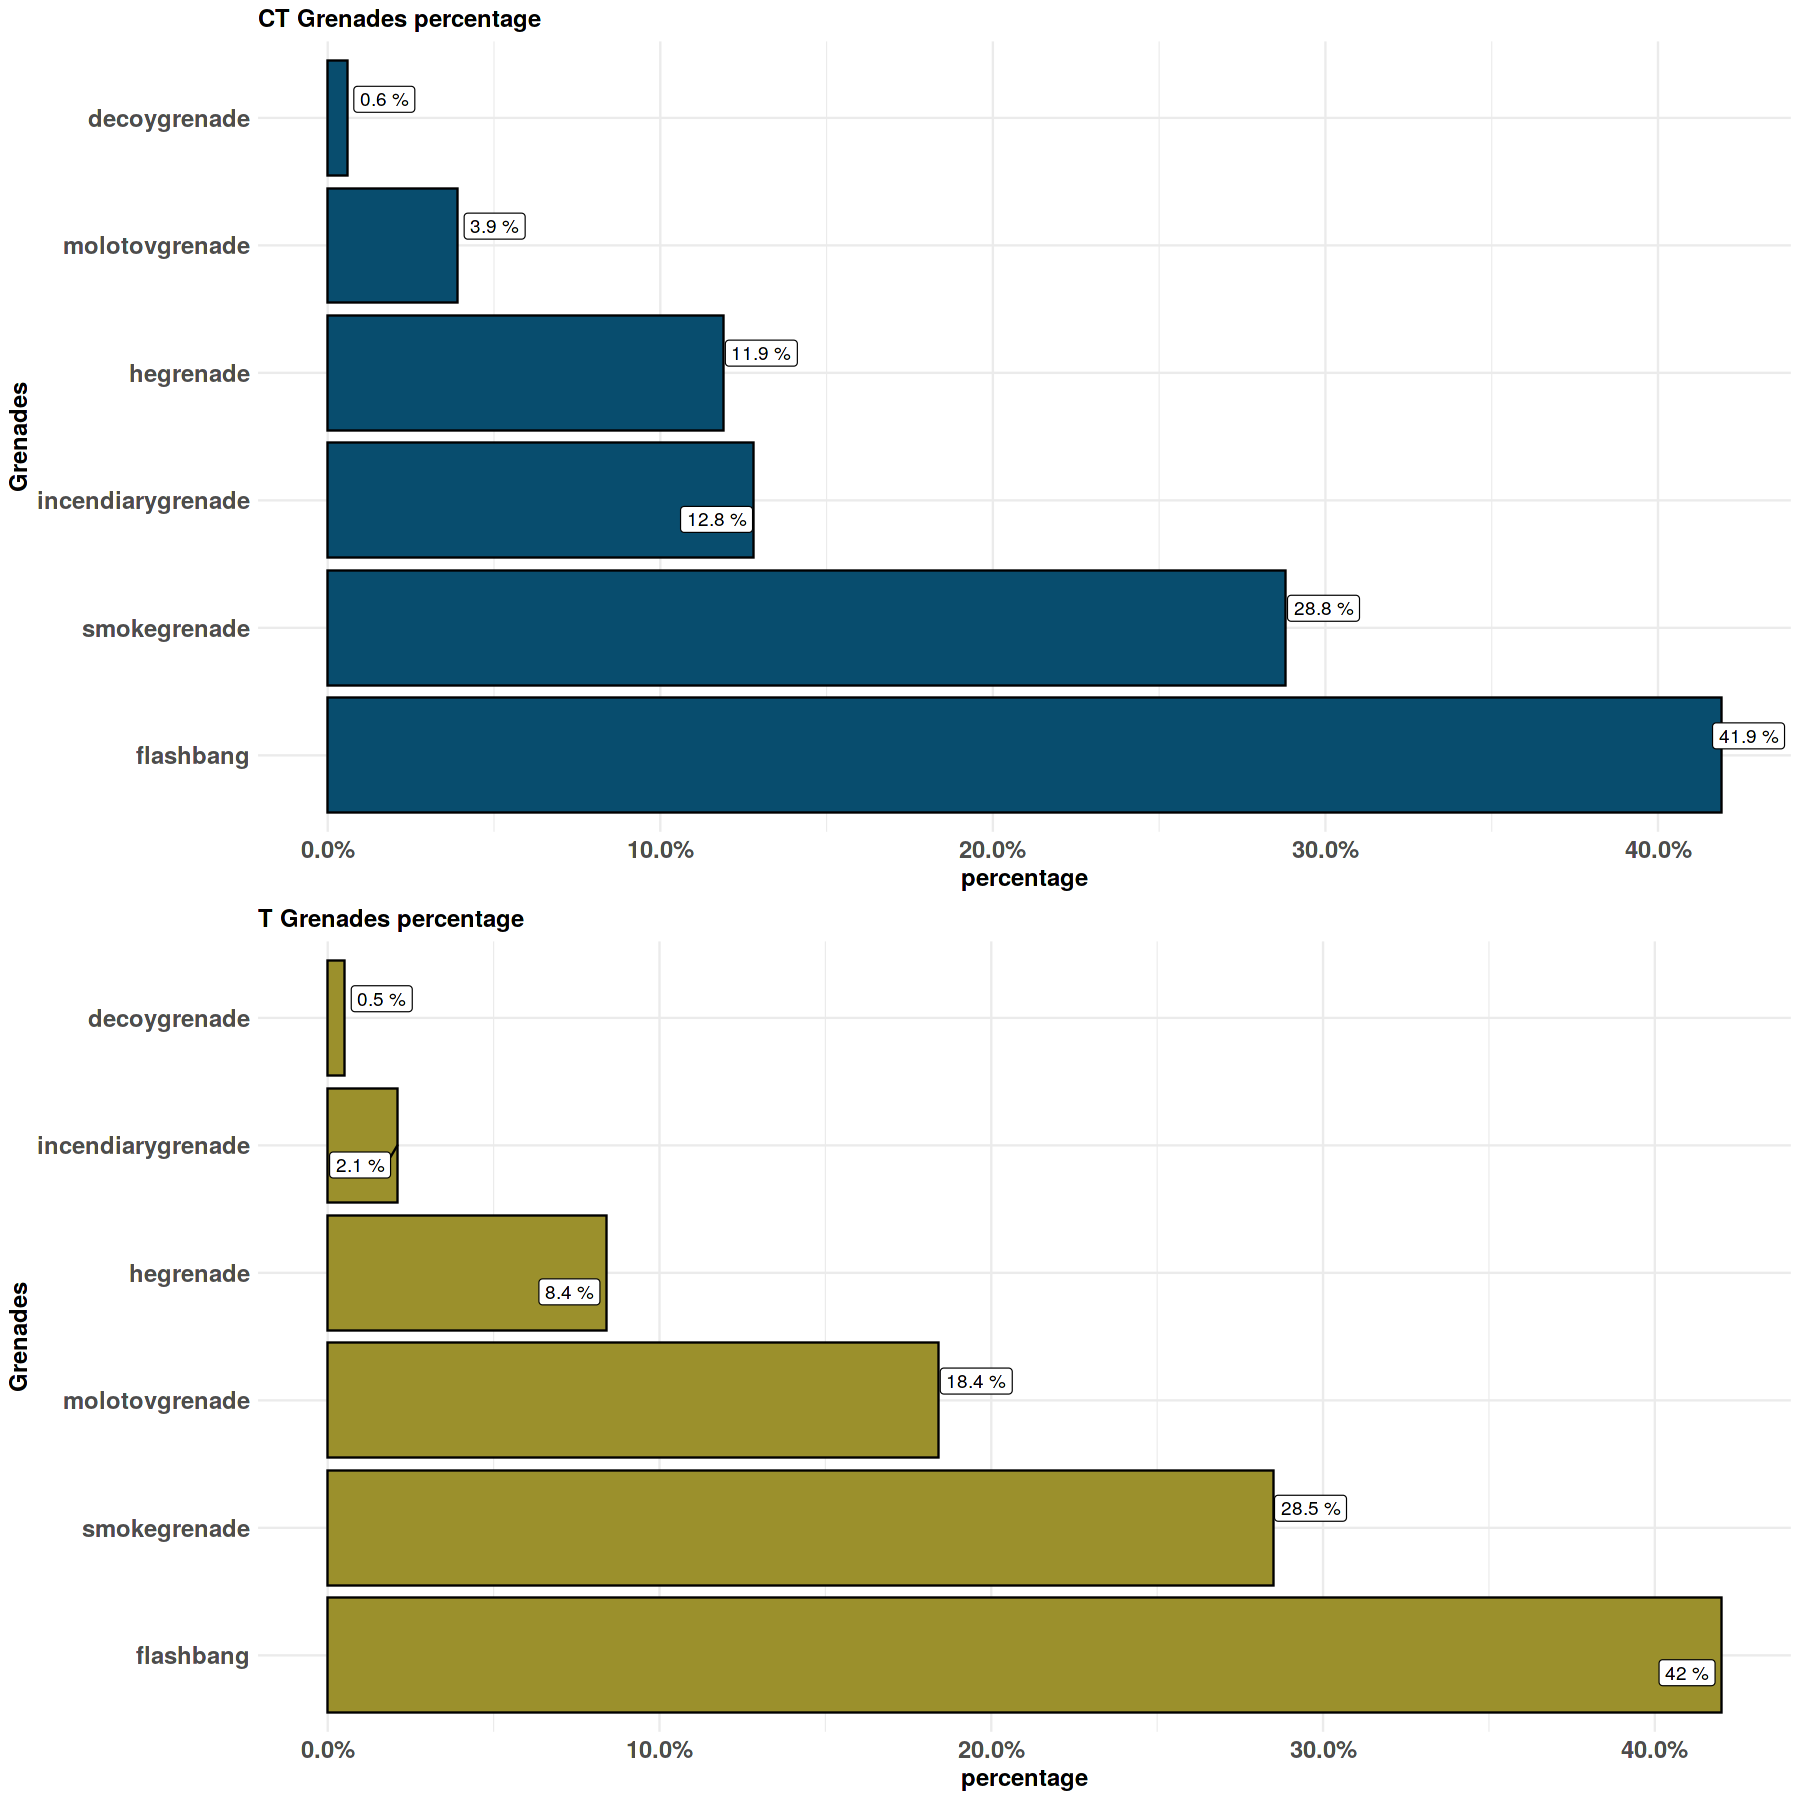

In [12]:
t_grenades = weapon_plot(column='t_grenade_',title='T Grenades percentage',
                        fill='#9b902c',ylab='Grenades')

ct_grenades = weapon_plot(column='ct_grenade_',title='CT Grenades percentage',
                        fill='#084d6e',ylab='Grenades')

plot_grid(plotlist=list(ct_grenades,t_grenades),ncol=1,nrow=2)

### Do defuse kits impact in round victory?

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



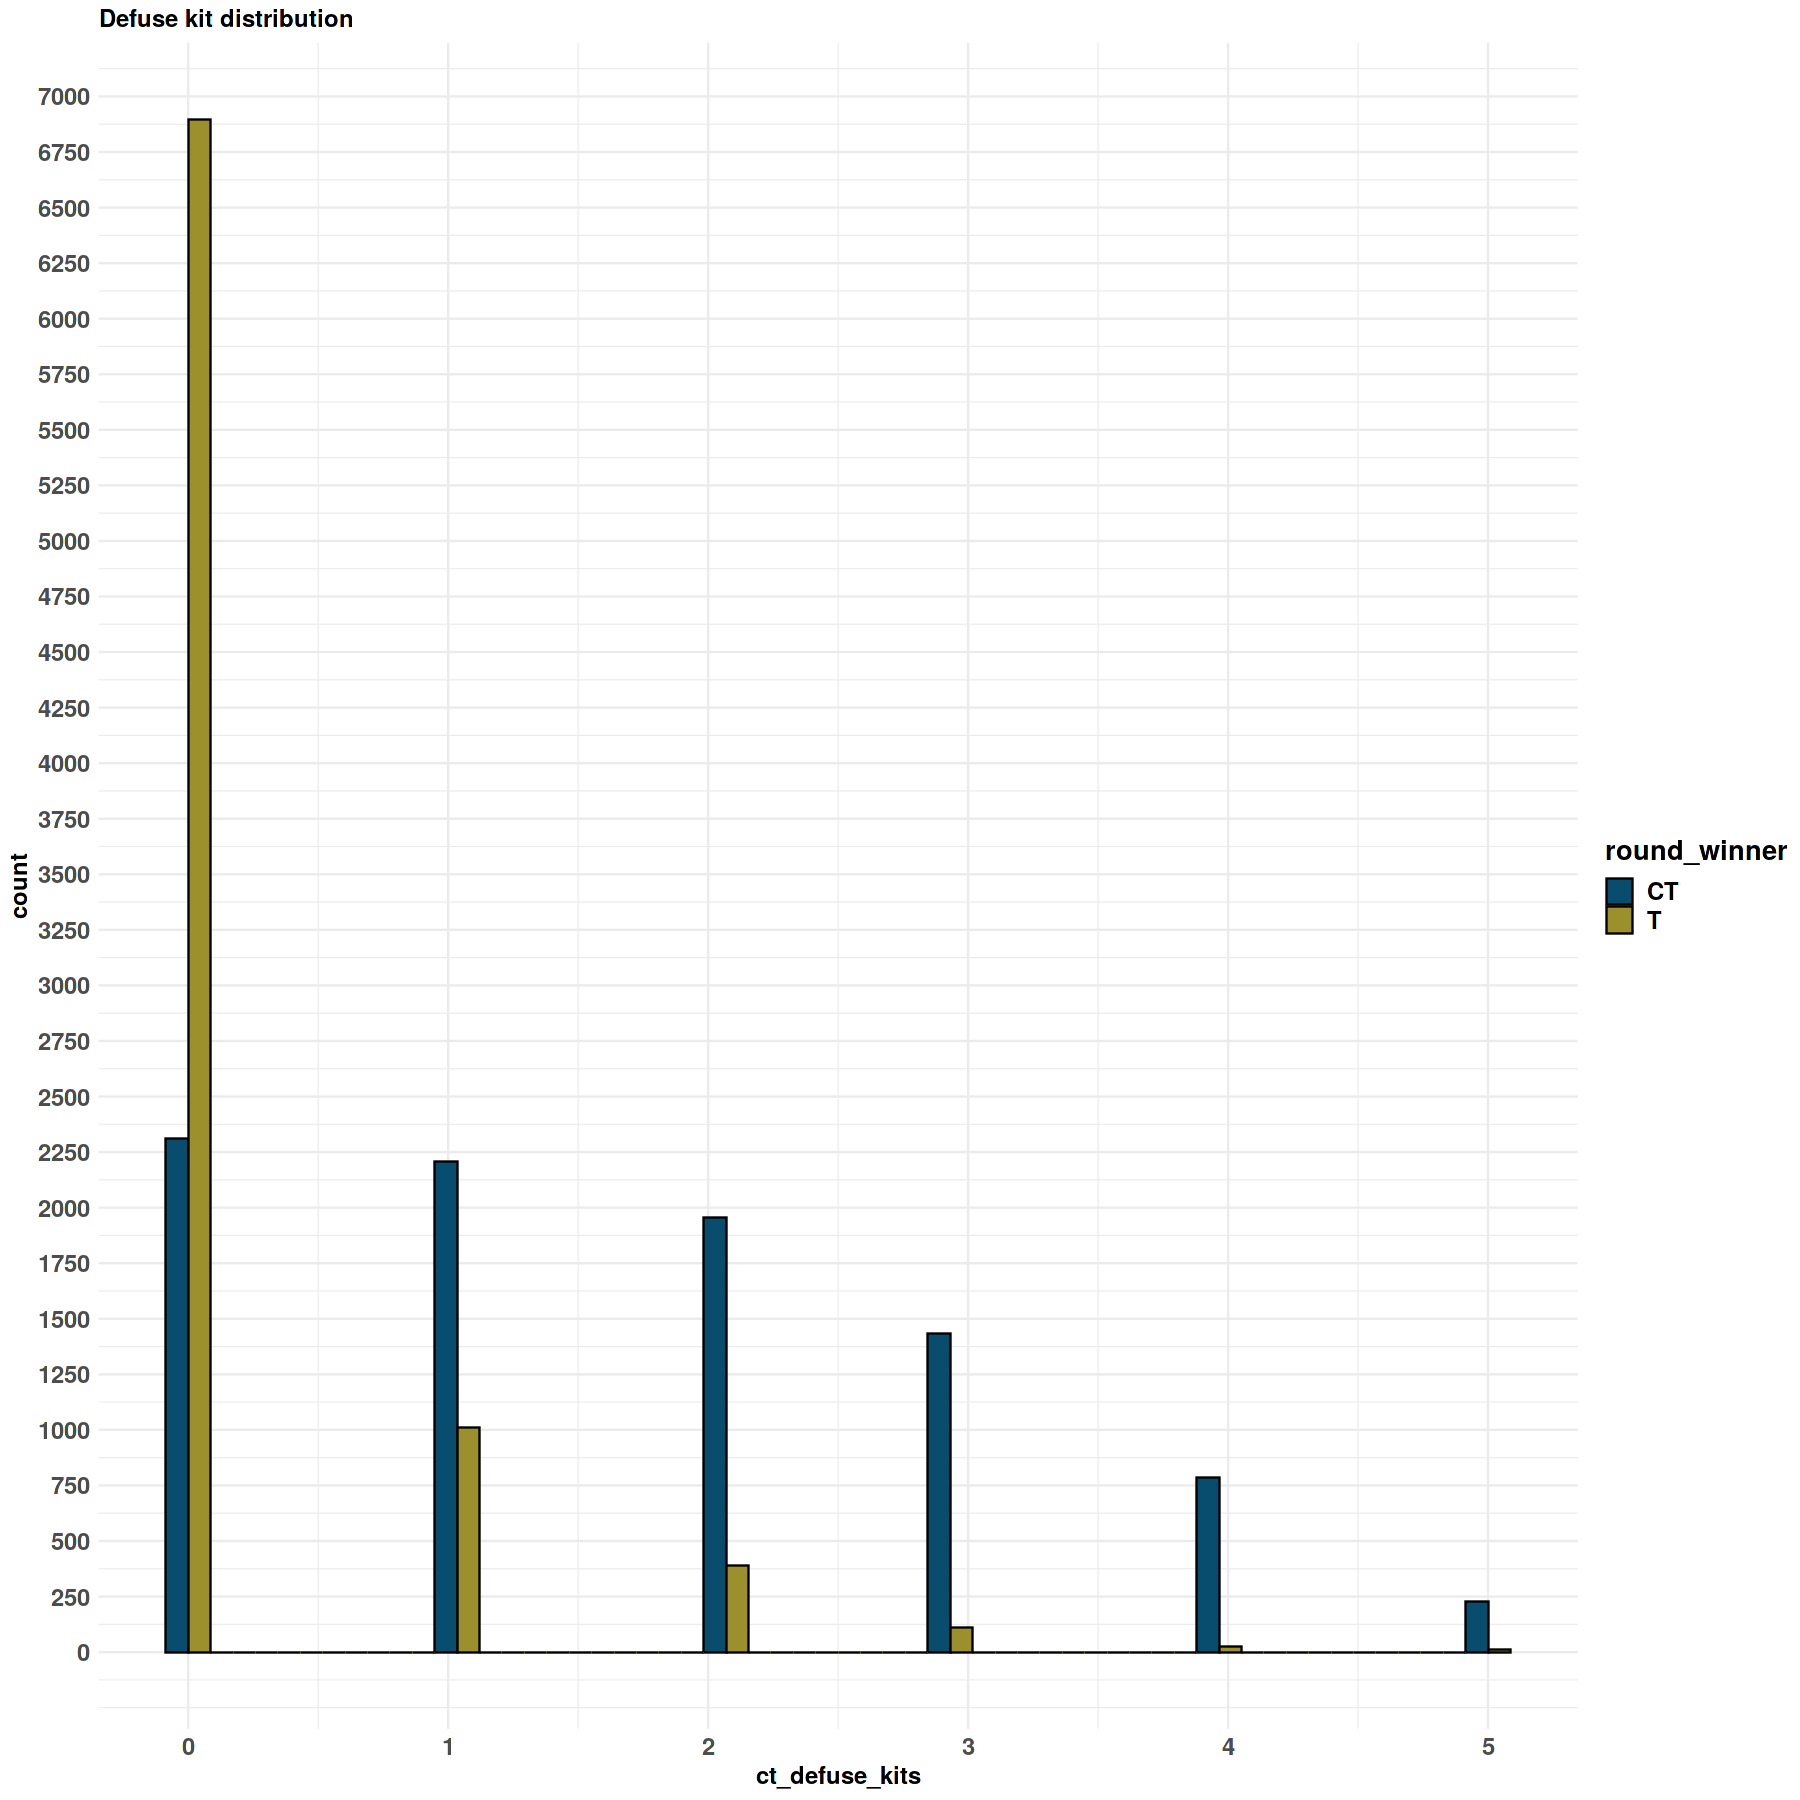

In [13]:
dt %>% group_by(match_id) %>% distinct(ct_score,t_score,.keep_all=TRUE) %>% 
    ungroup() %>% select(round_winner,ct_defuse_kits) %>%
    ggplot(aes(x=ct_defuse_kits,fill=round_winner))+
    geom_histogram(aes(y=..count..),position='dodge',color='black') +
    scale_y_continuous(breaks=seq(0,7000,250))+
    ggtitle('Defuse kit distribution')+
    ctr_fill + 
    standard_theme

This shows the importance of defuse kits, they allow the rapid defuse of the bomb and apparently increase chance of winning the round. Does this hypothesis holds for all maps?

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



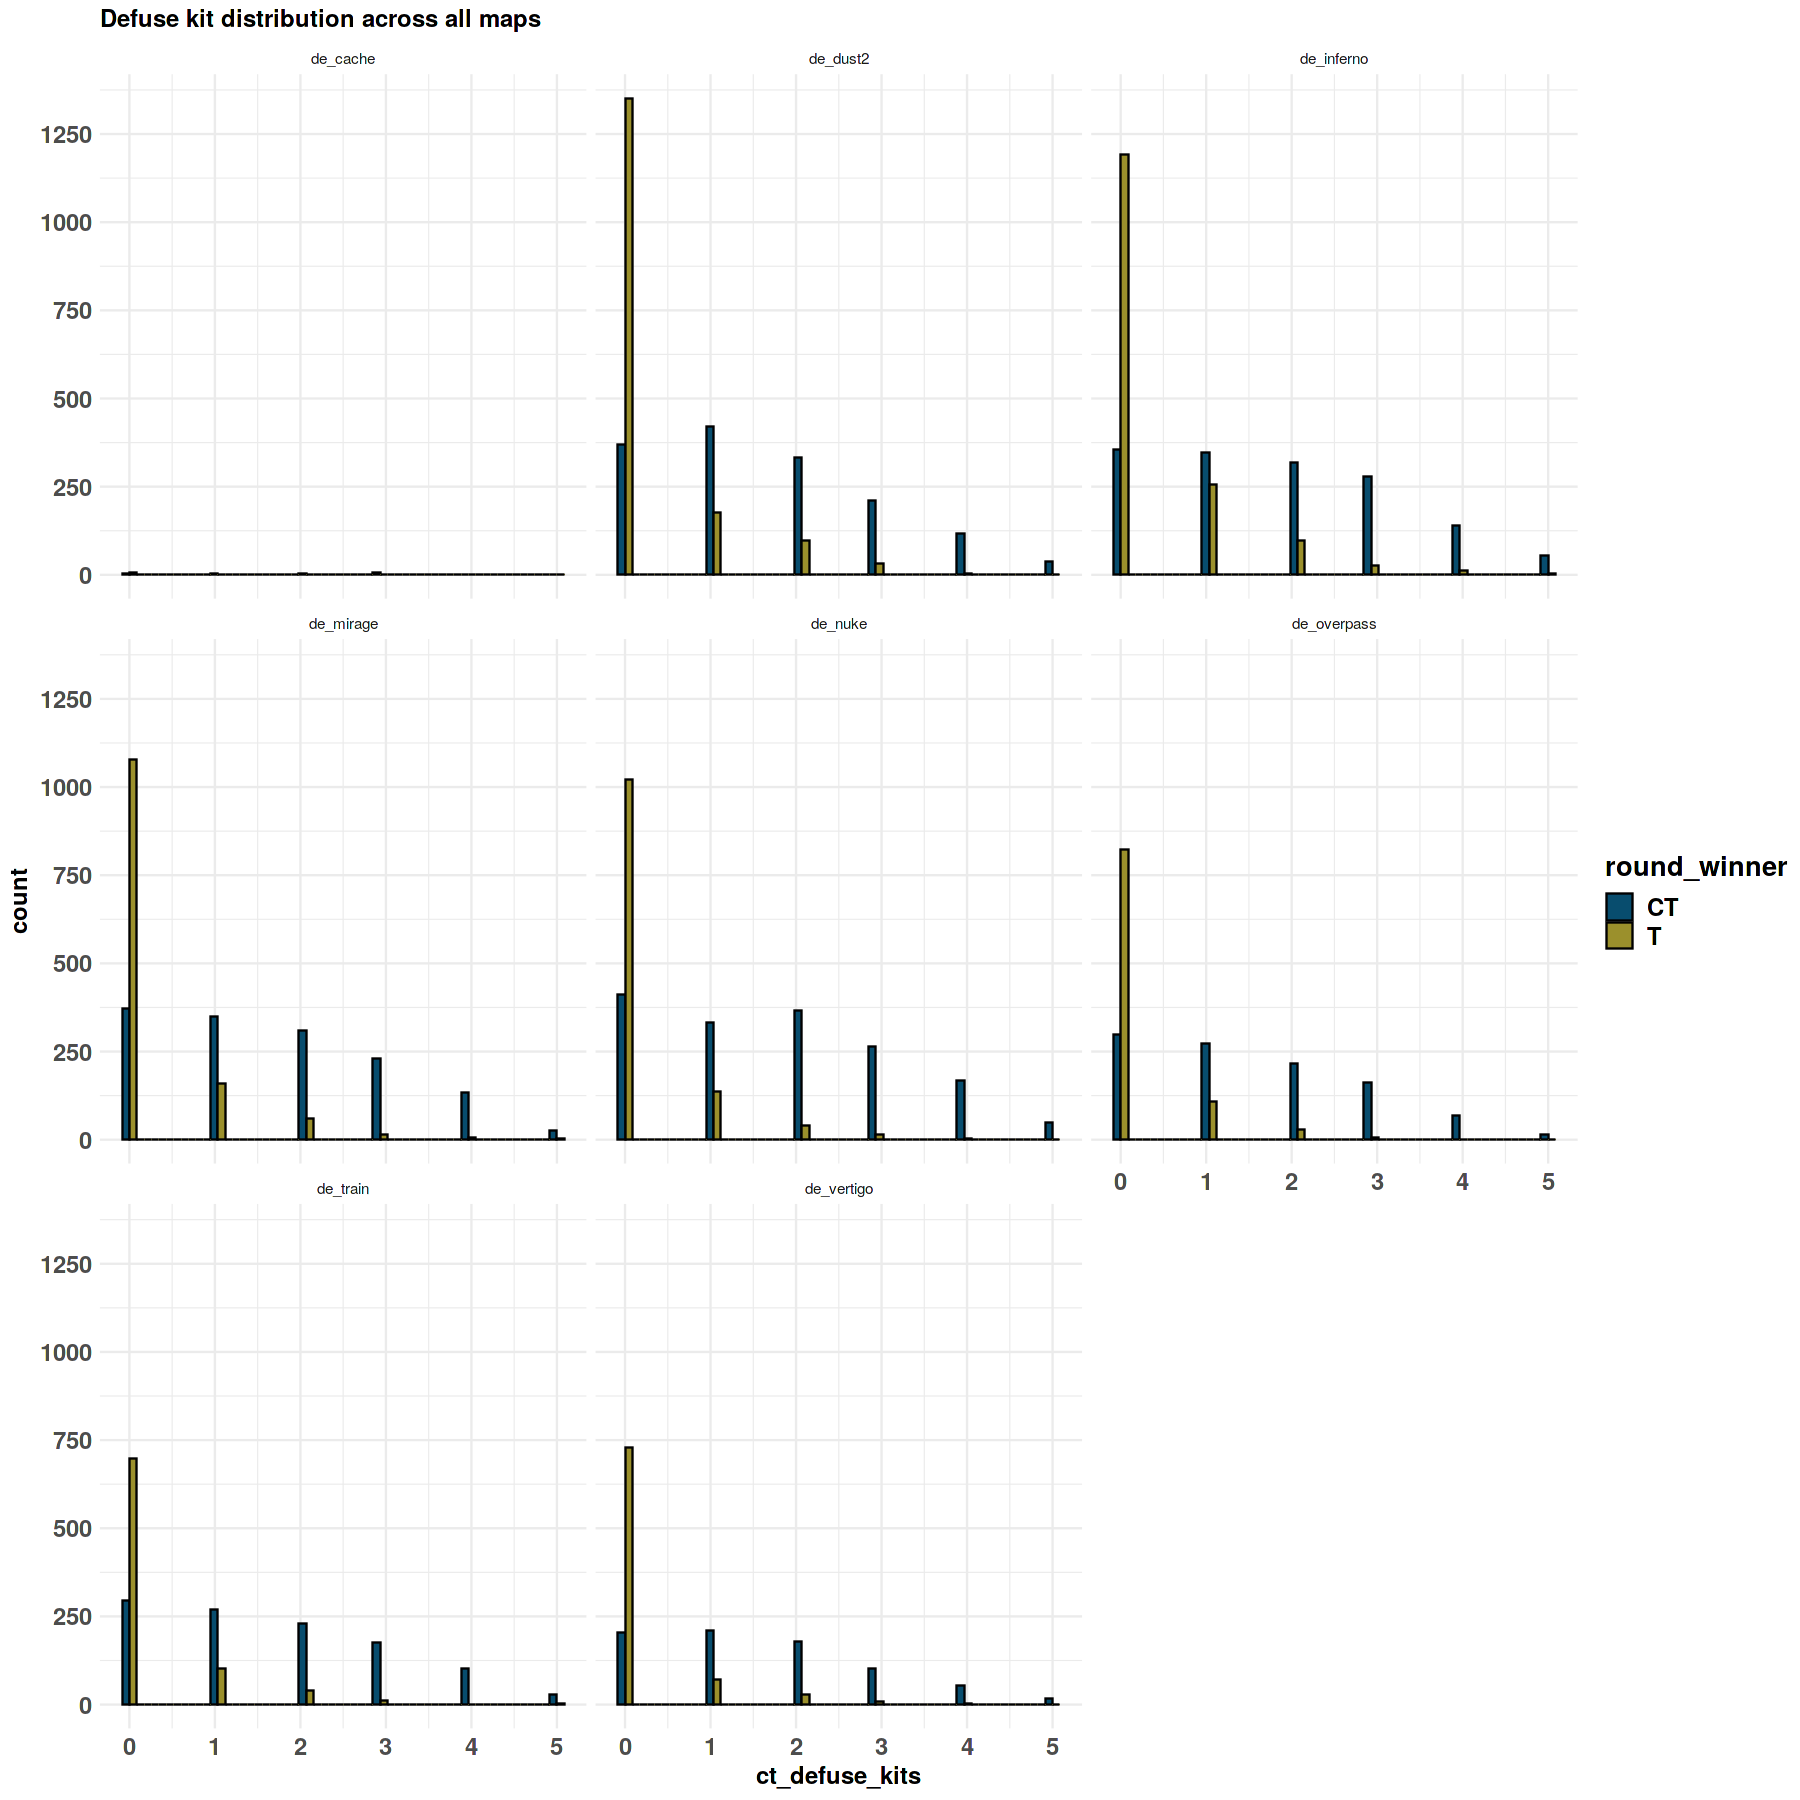

In [14]:
dt %>% group_by(match_id) %>% distinct(ct_score,t_score,.keep_all=TRUE) %>% 
    ungroup() %>% select(map,round_winner,ct_defuse_kits) %>%
    ggplot(aes(x=ct_defuse_kits,fill=round_winner))+
    geom_histogram(aes(y=..count..),position='dodge',color='black') +
    facet_wrap(.~map)+
    scale_y_continuous(breaks=seq(0,1250,250))+
    ggtitle('Defuse kit distribution across all maps')+
    ctr_fill + 
    standard_theme

### How are lives, money and armor distributed?

Picking joint bandwidth of 0.0931

Picking joint bandwidth of 0.107



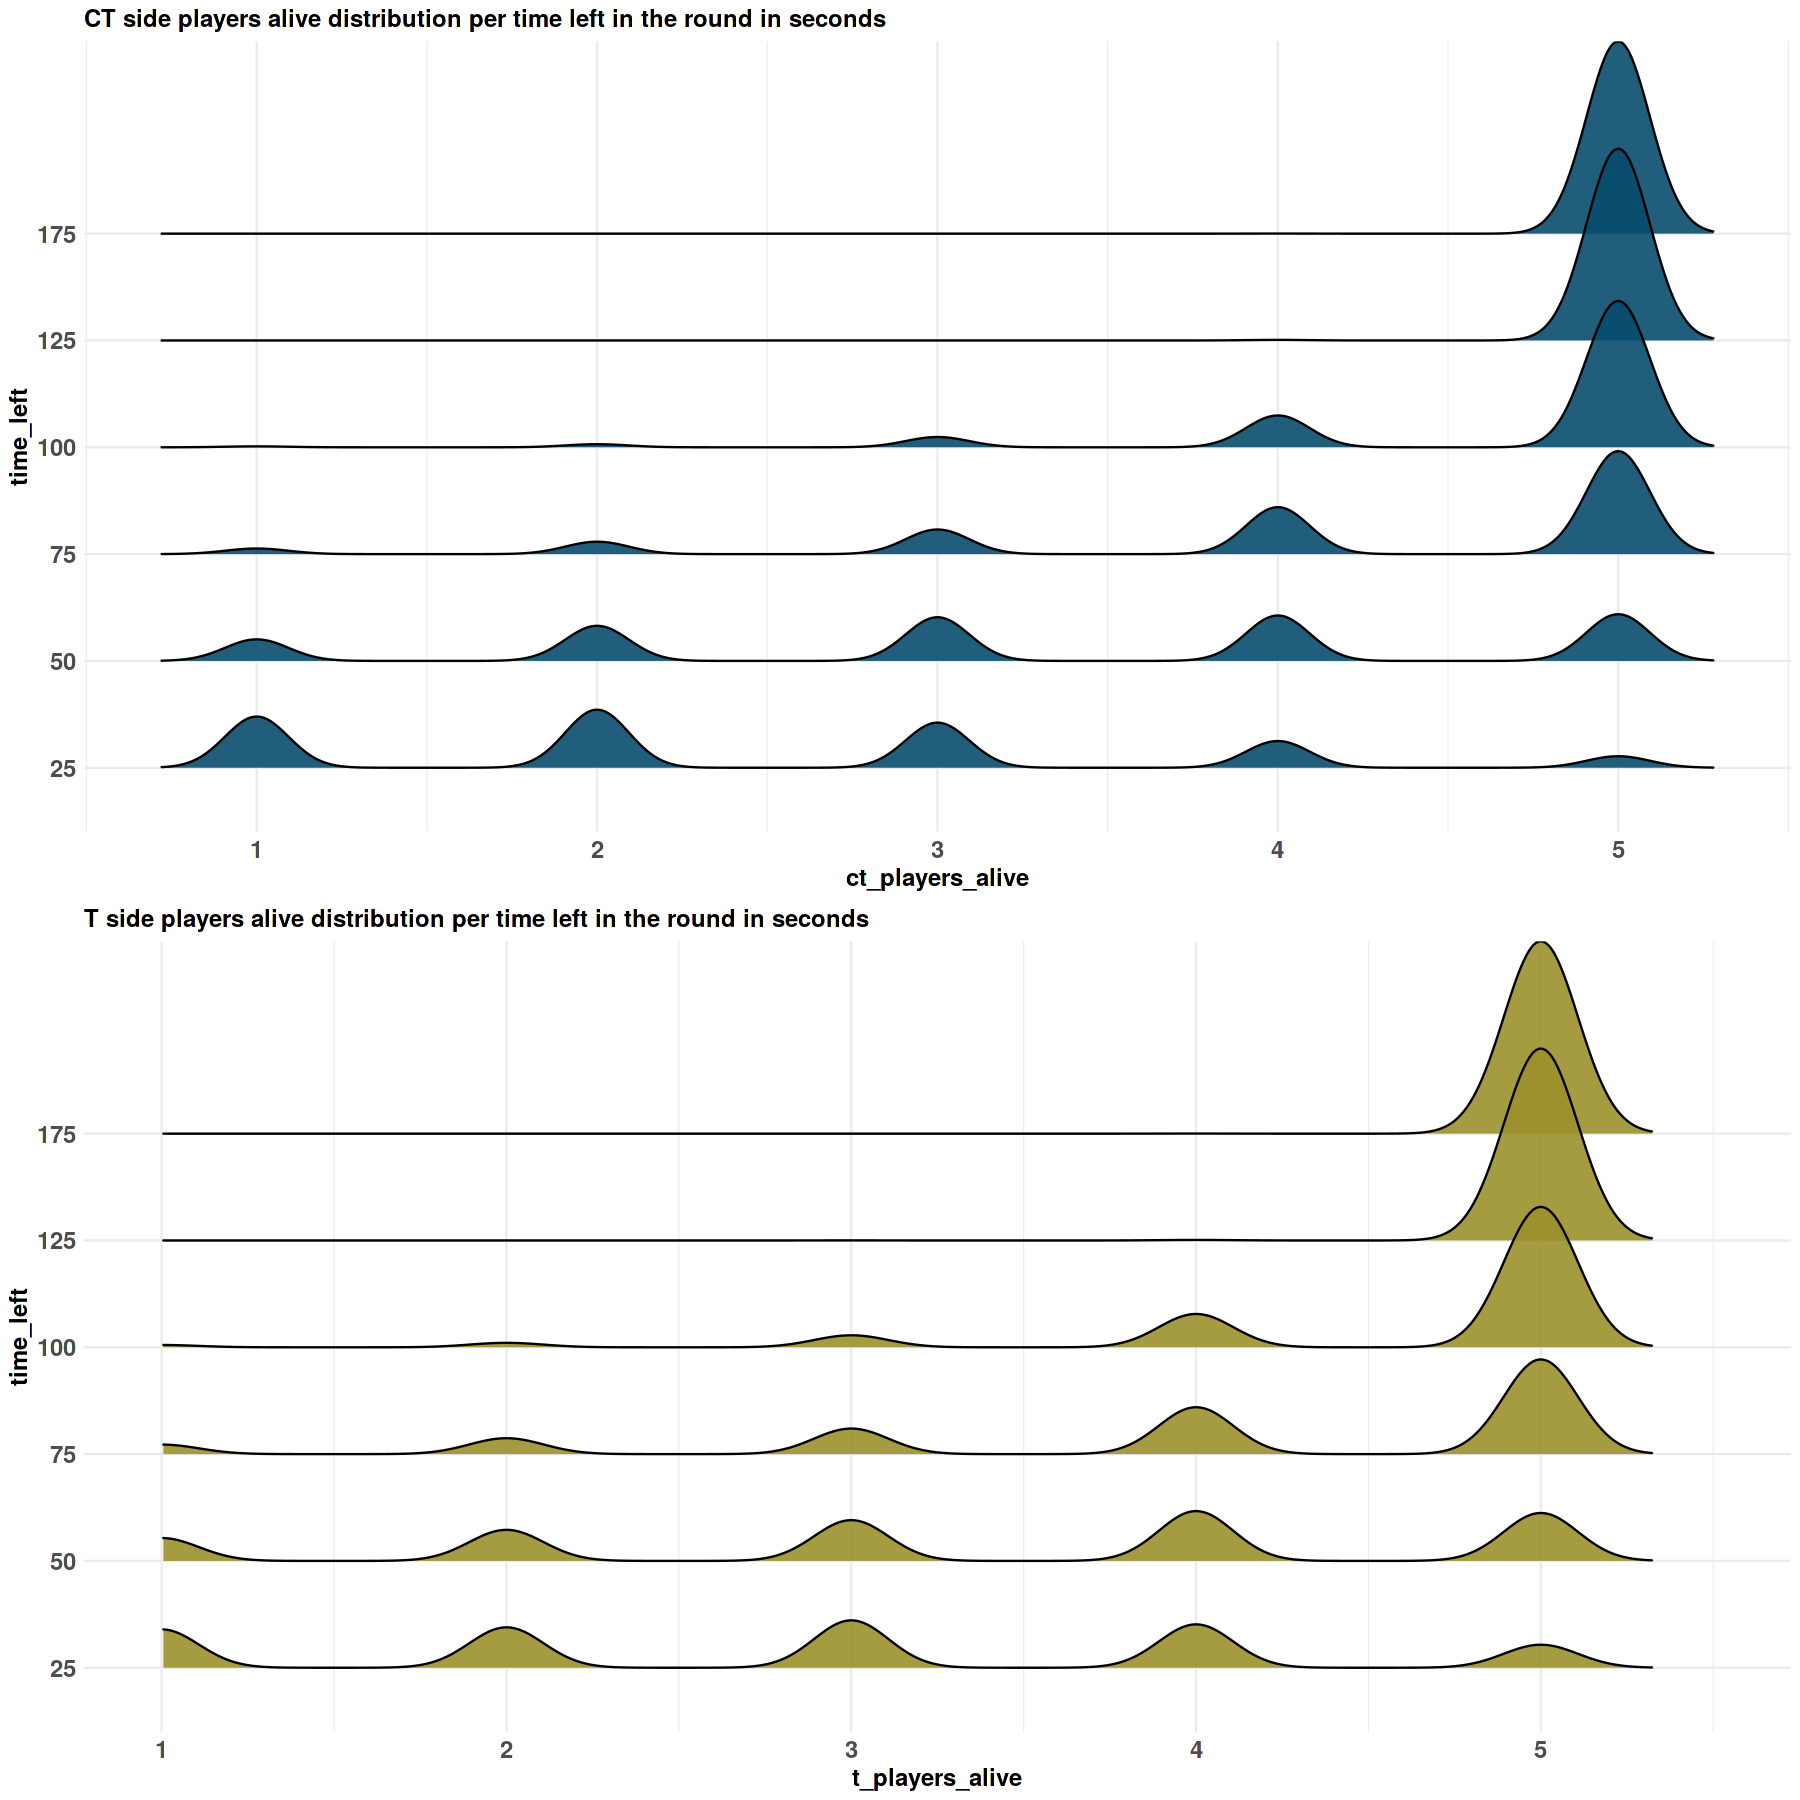

In [15]:
ct = dt %>% select(time_left,ct_players_alive) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=ct_players_alive,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#084d6e') +
    ggtitle('CT side players alive distribution per time left in the round in seconds')+
    standard_theme

t = dt %>% select(time_left,t_players_alive) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=t_players_alive,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#9b902c') +
    ggtitle('T side players alive distribution per time left in the round in seconds') +
    scale_x_continuous(limits = c(1,5.5))+
    standard_theme

plot_grid(plotlist=list(ct,t),ncol=1,nrow=2)

Picking joint bandwidth of 16.3

Picking joint bandwidth of 16.9



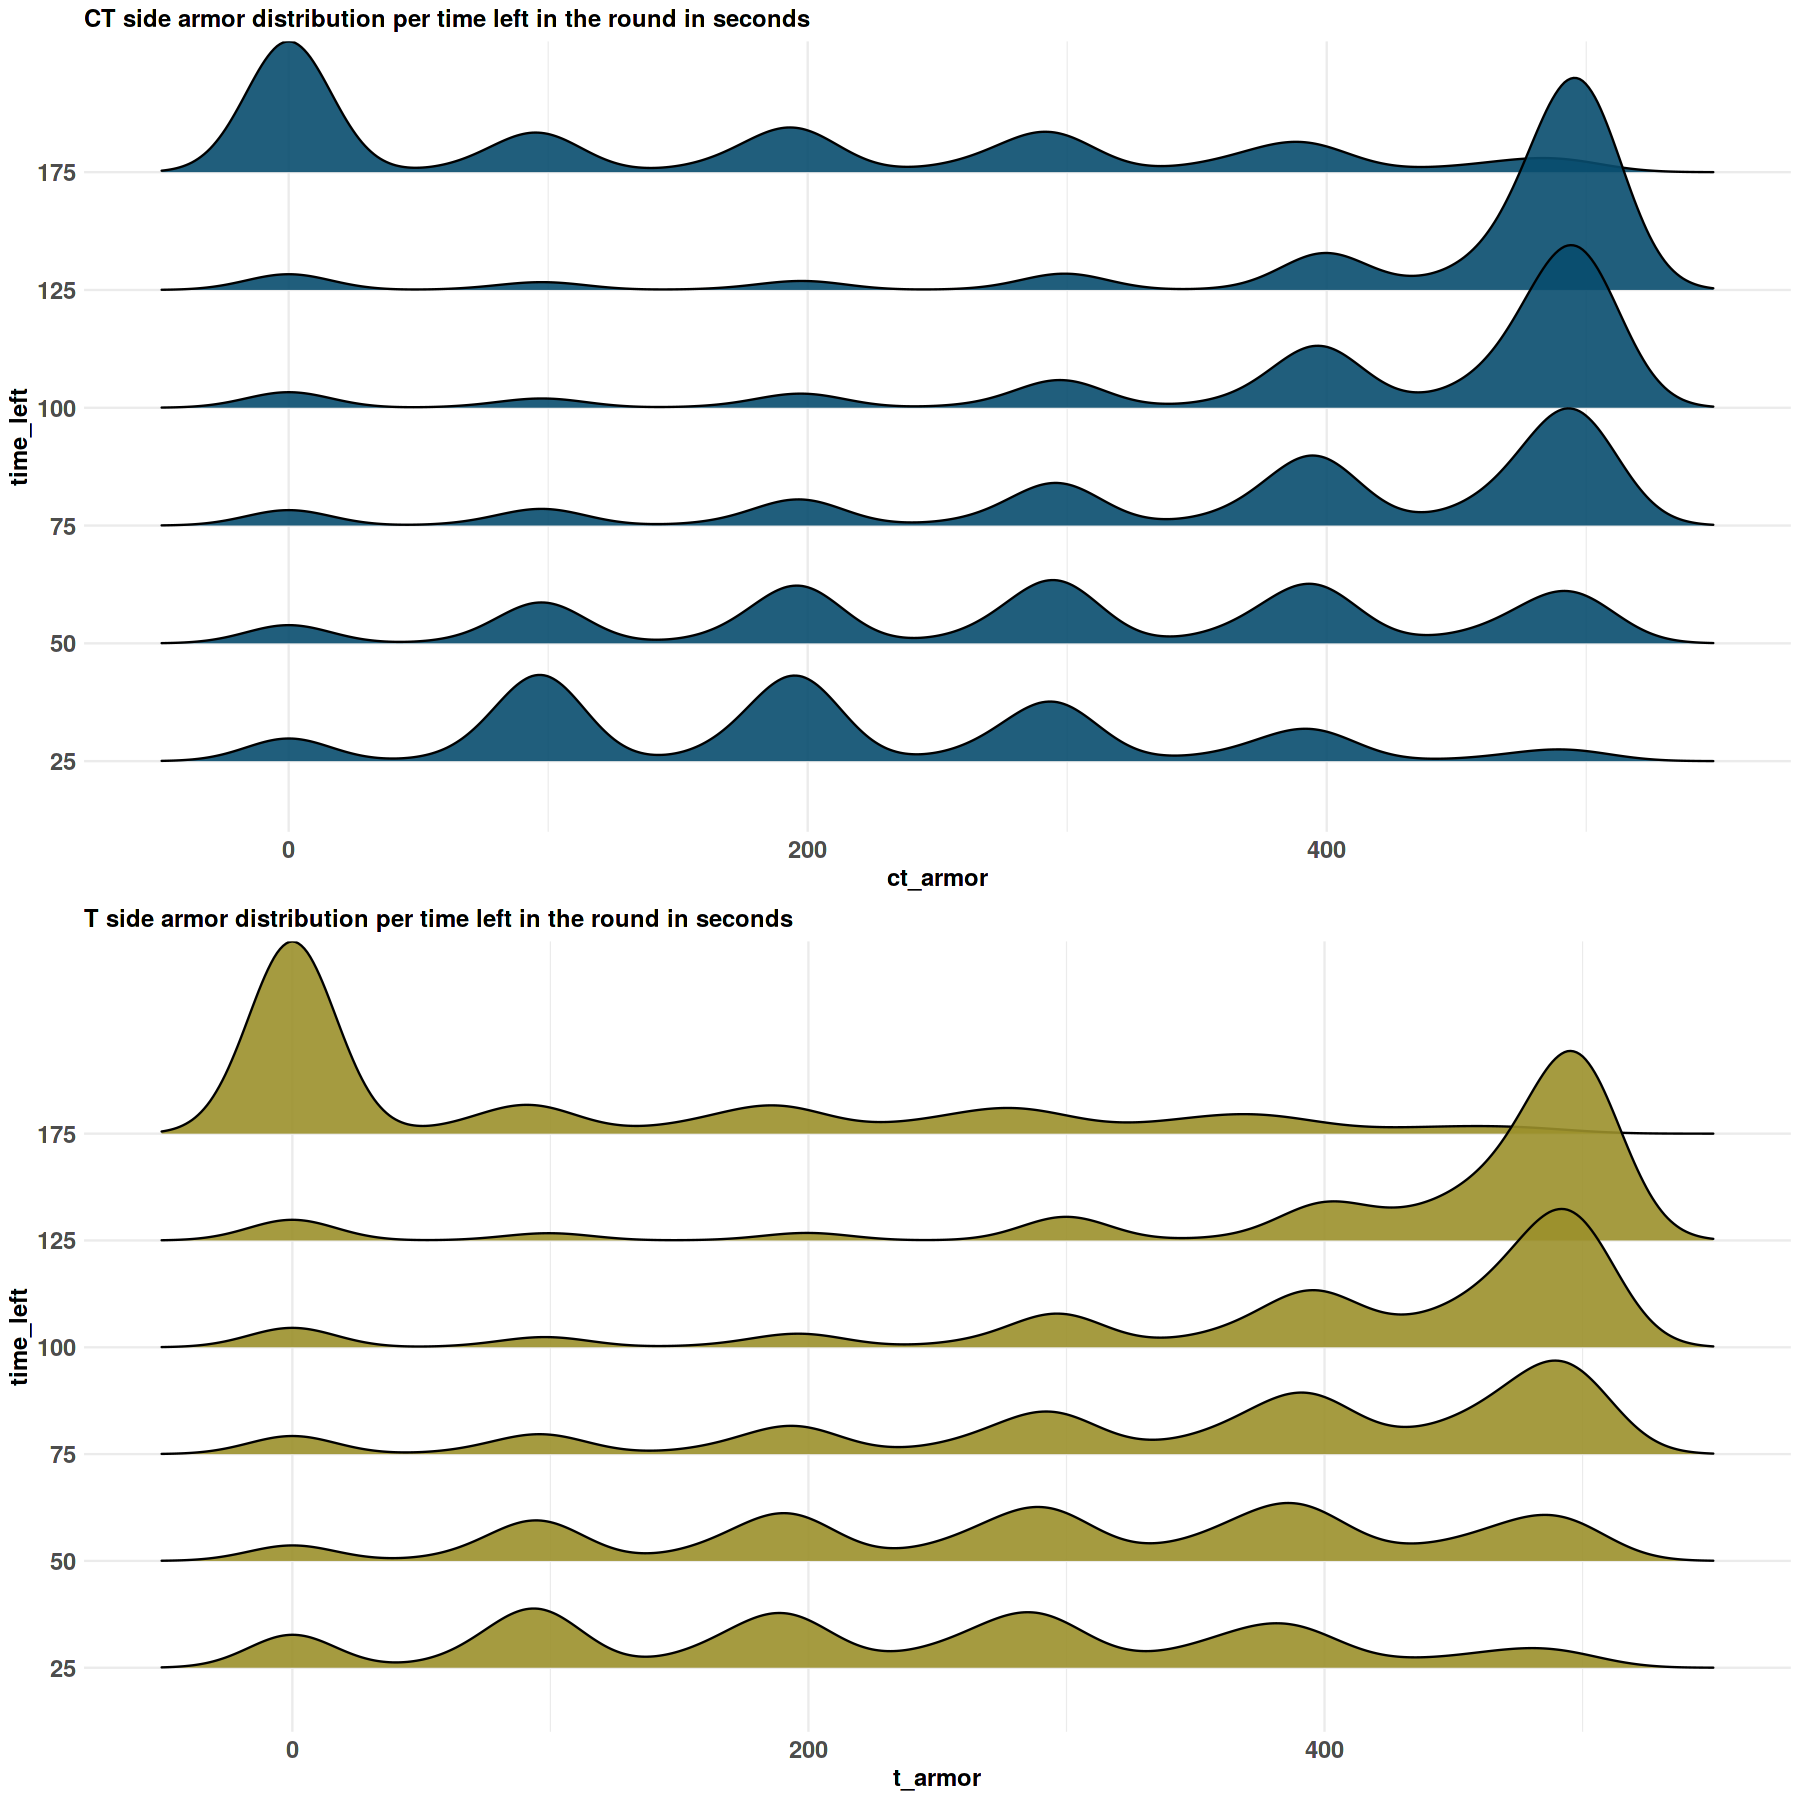

In [16]:
ct = dt %>% select(time_left,ct_armor) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=ct_armor,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#084d6e') +
    ggtitle('CT side armor distribution per time left in the round in seconds')+
    standard_theme

t = dt %>% select(time_left,t_armor) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=t_armor,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#9b902c') +
    ggtitle('T side armor distribution per time left in the round in seconds') +
    standard_theme

plot_grid(plotlist=list(ct,t),ncol=1,nrow=2)

Picking joint bandwidth of 932

Picking joint bandwidth of 1090



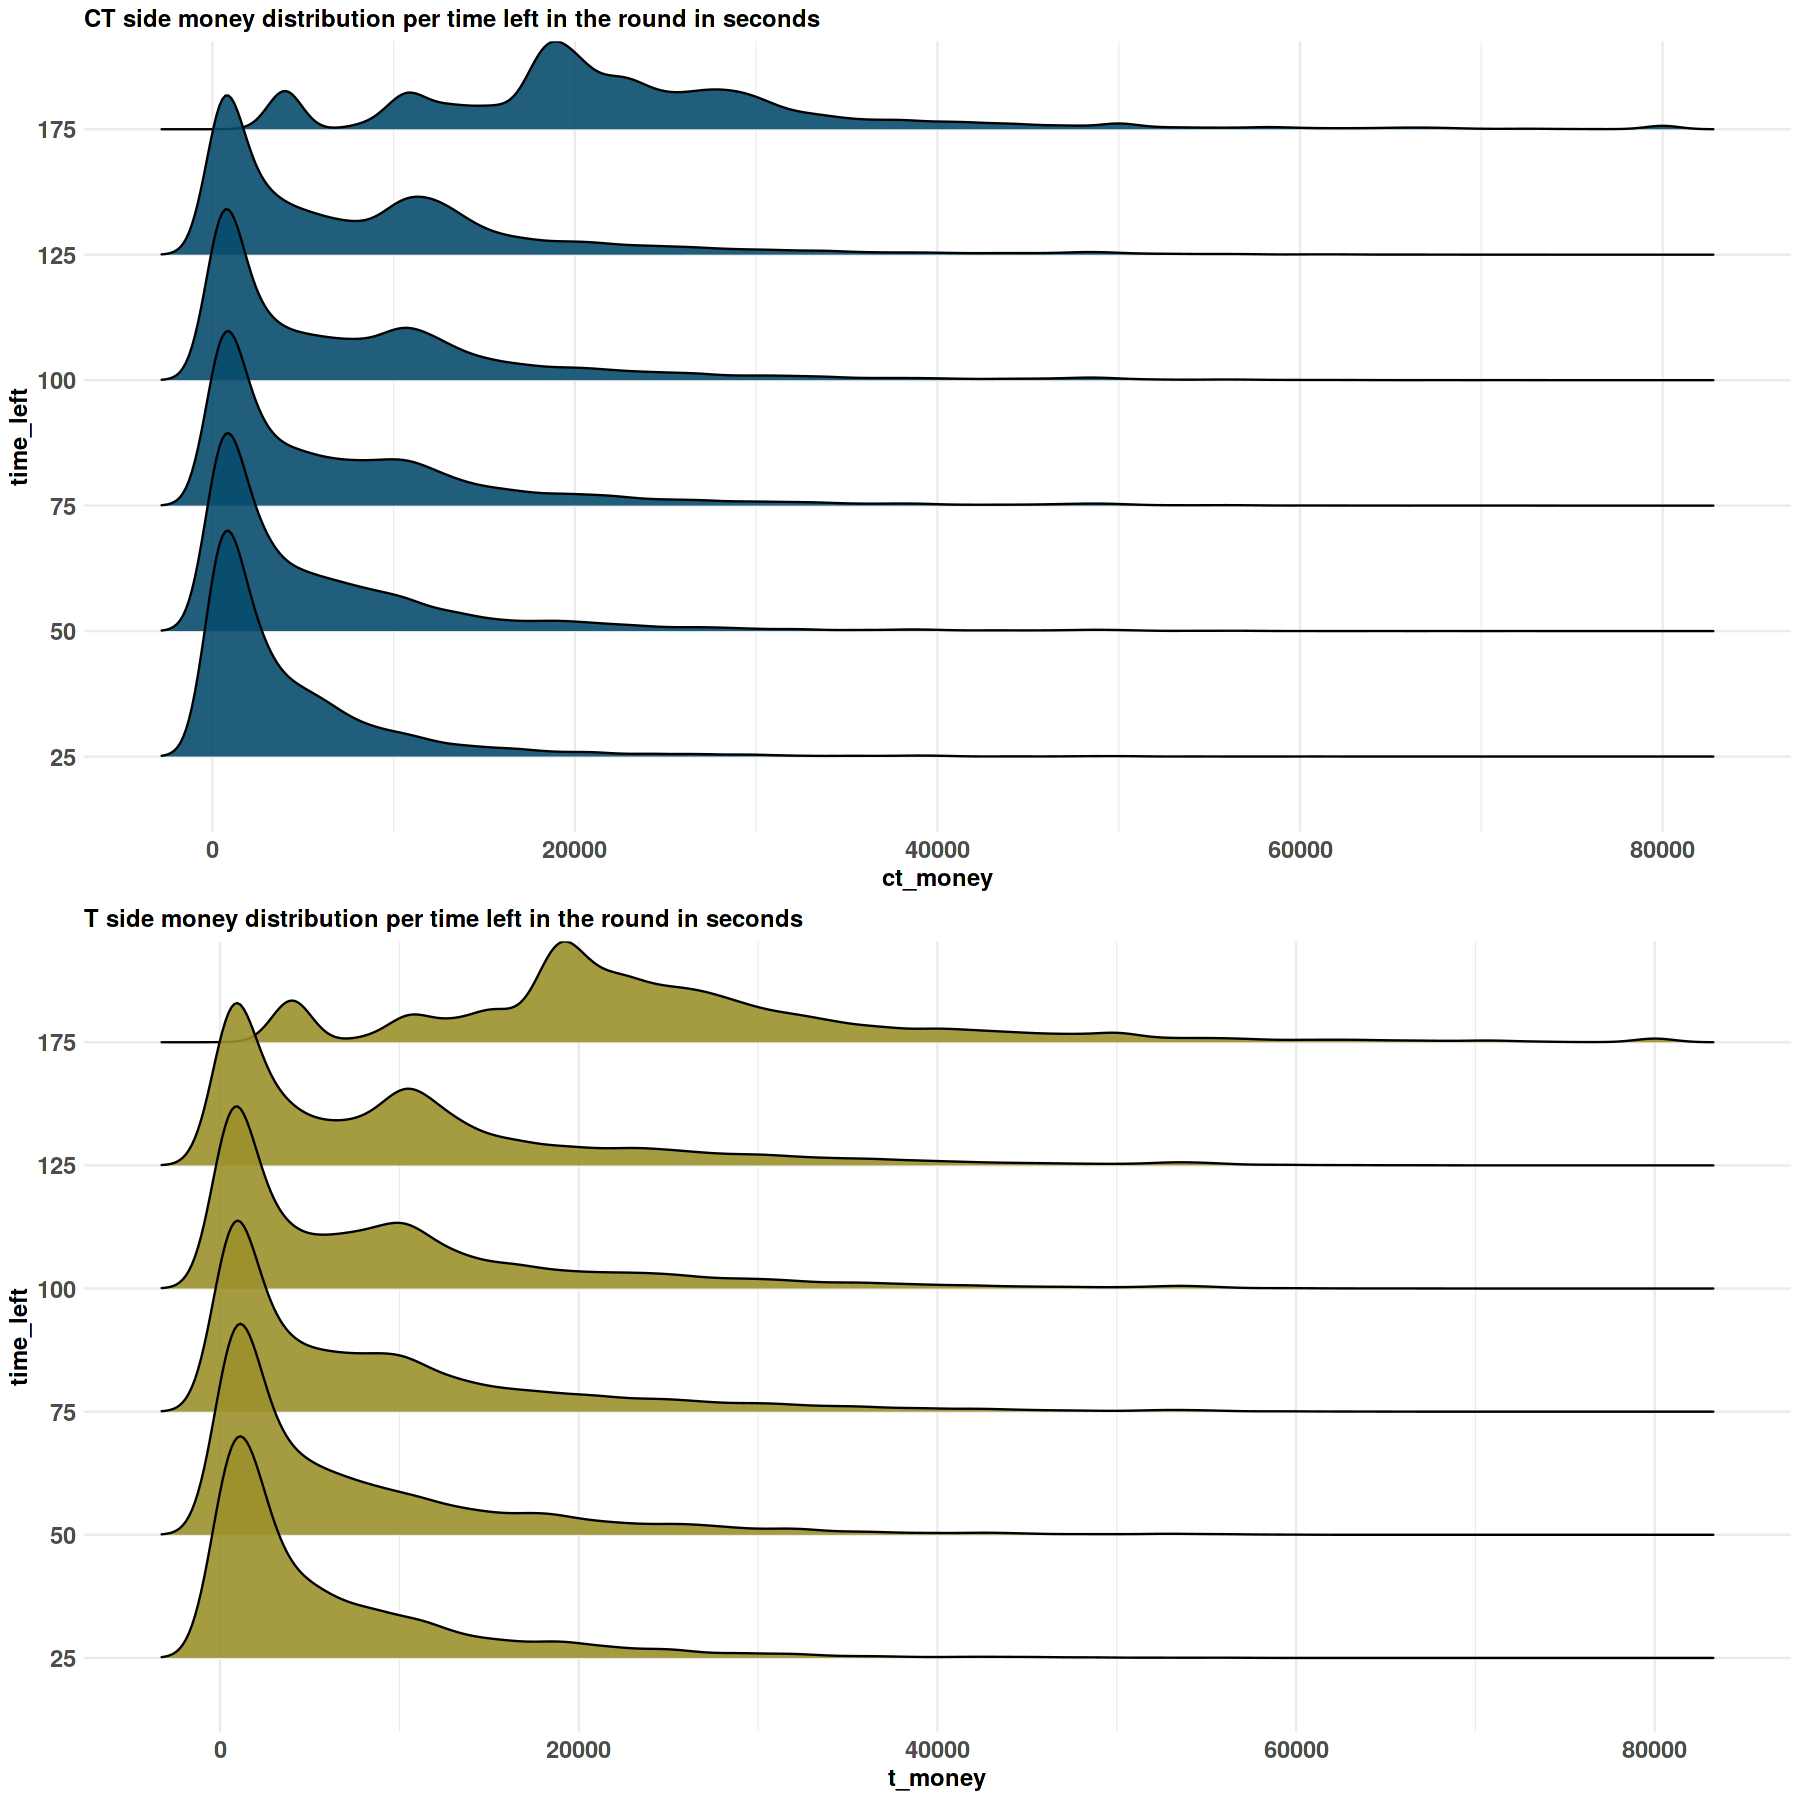

In [17]:
ct = dt %>% select(time_left,ct_money) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=ct_money,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#084d6e') +
    ggtitle('CT side money distribution per time left in the round in seconds')+
    standard_theme

t = dt %>% select(time_left,t_money) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=t_money,y=time_left)) +
    geom_density_ridges(alpha=0.9, bins=30,fill='#9b902c') +
    ggtitle('T side money distribution per time left in the round in seconds') +
    standard_theme

plot_grid(plotlist=list(ct,t),ncol=1,nrow=2)

### At which timestamp is the bomb planted?

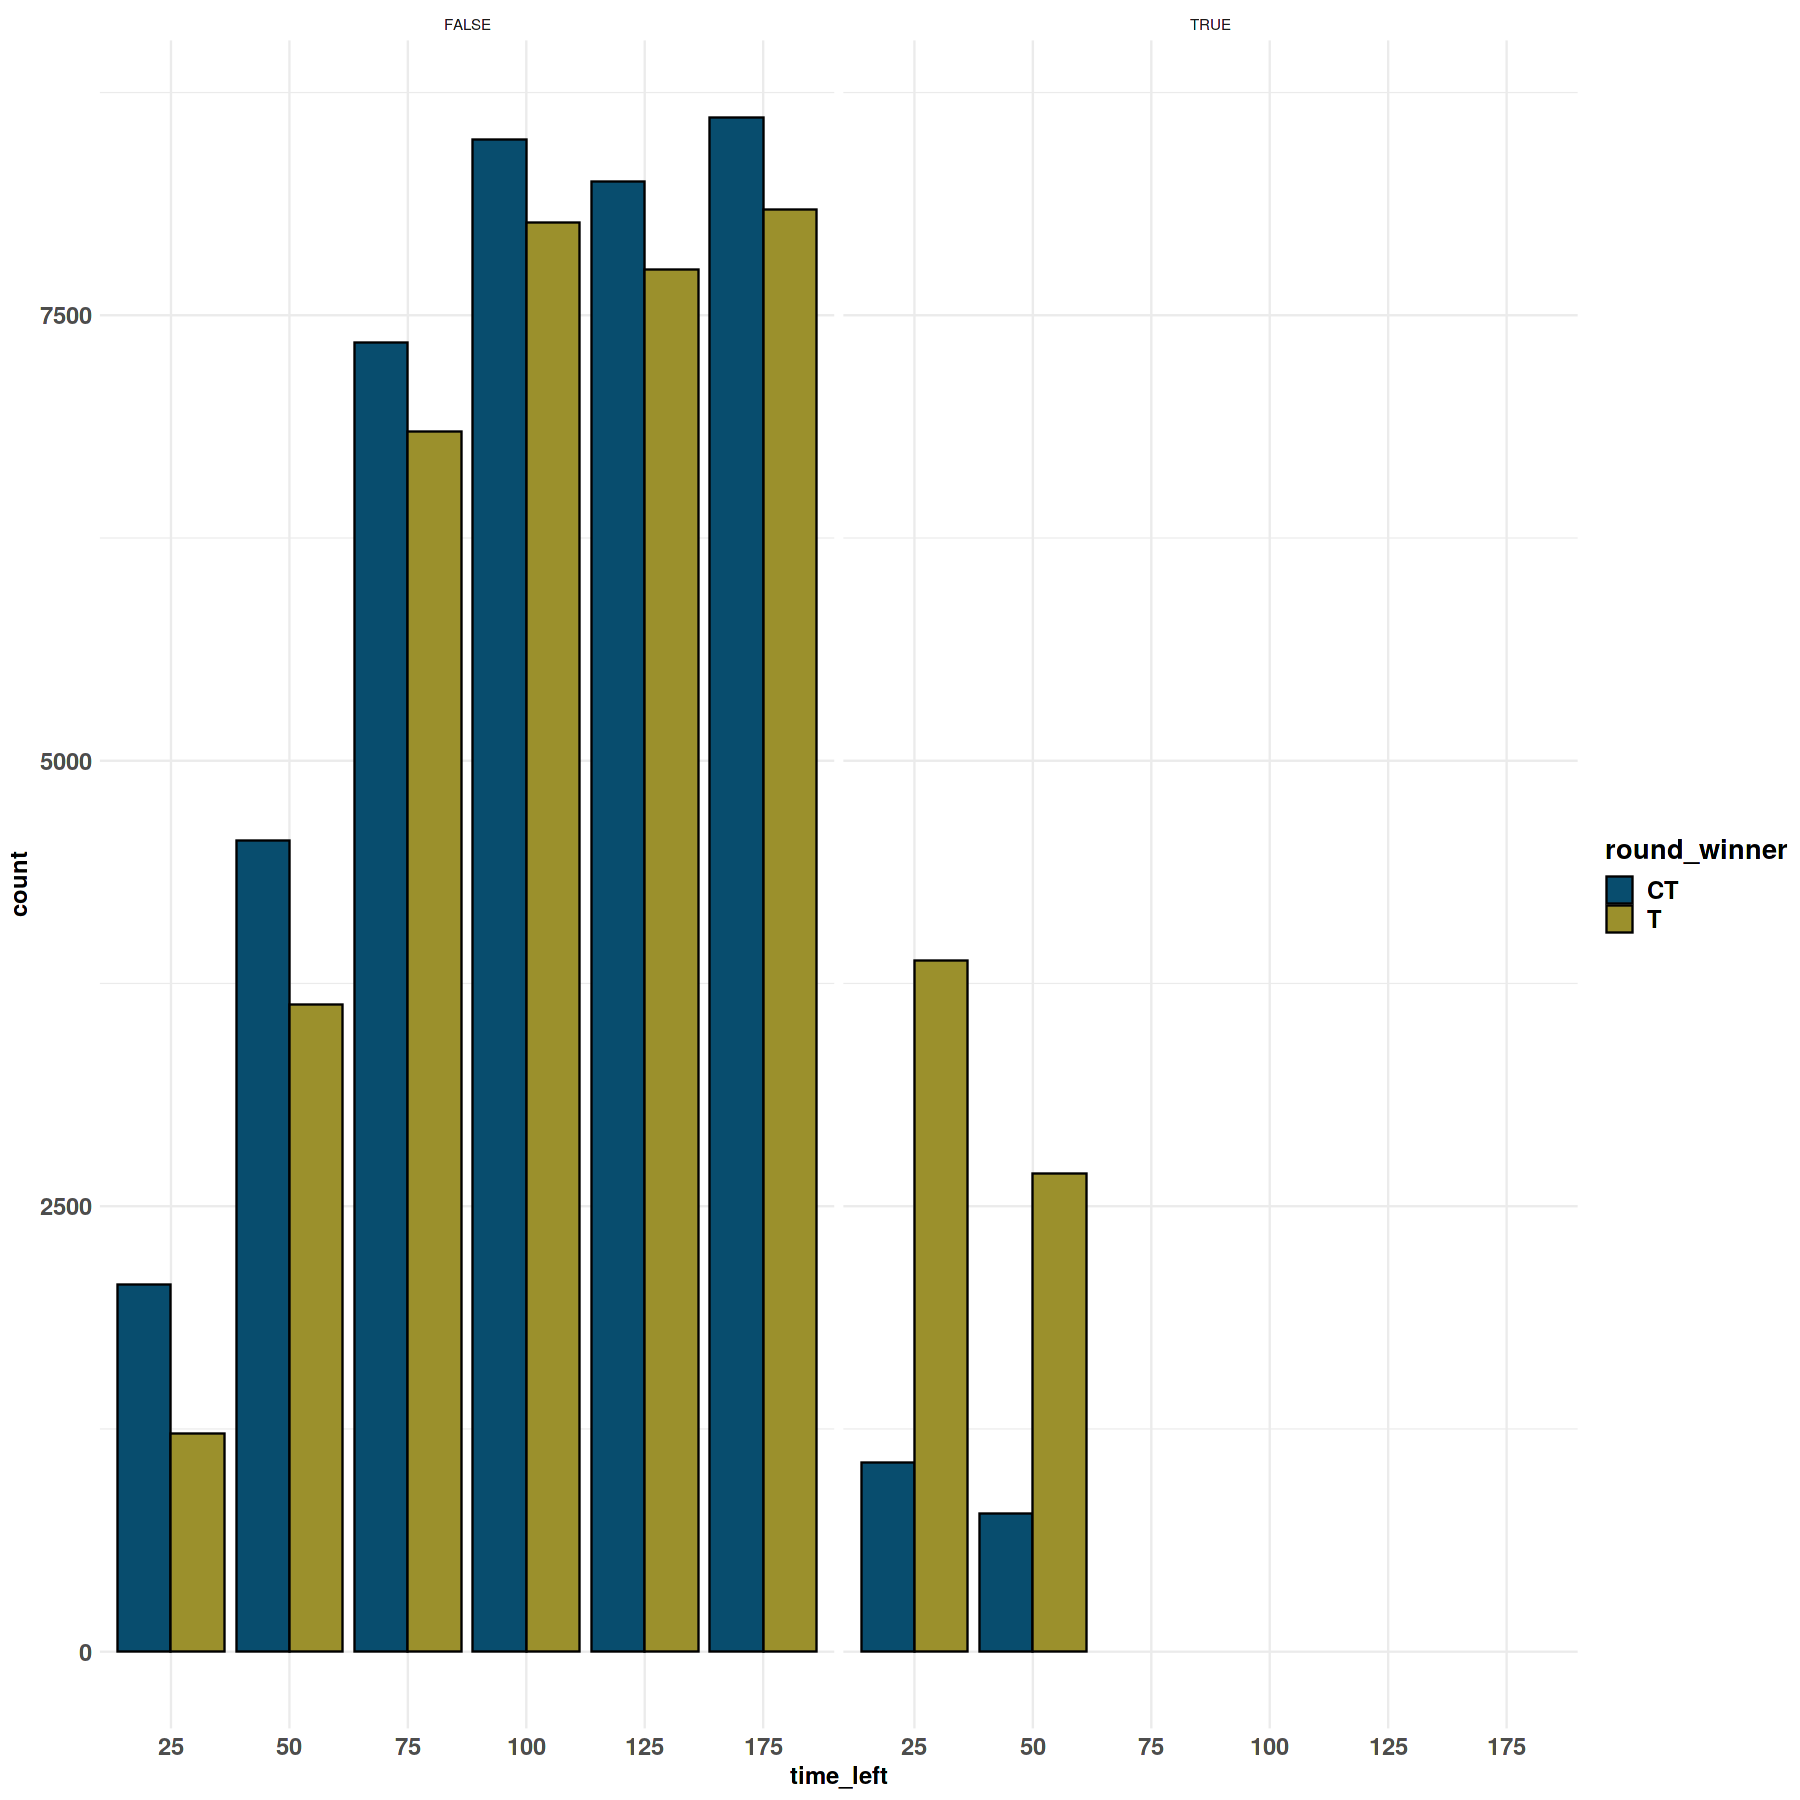

In [18]:
dt %>% select(time_left,bomb_planted,round_winner) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=time_left,fill=round_winner))+
    geom_histogram(stat="count",position='dodge',color='black') +
    facet_wrap(.~bomb_planted)+
    ctr_fill +
    standard_theme

It seems that CT wins more despite of not having planted the bomb, this could be a effect of the timestamp division.

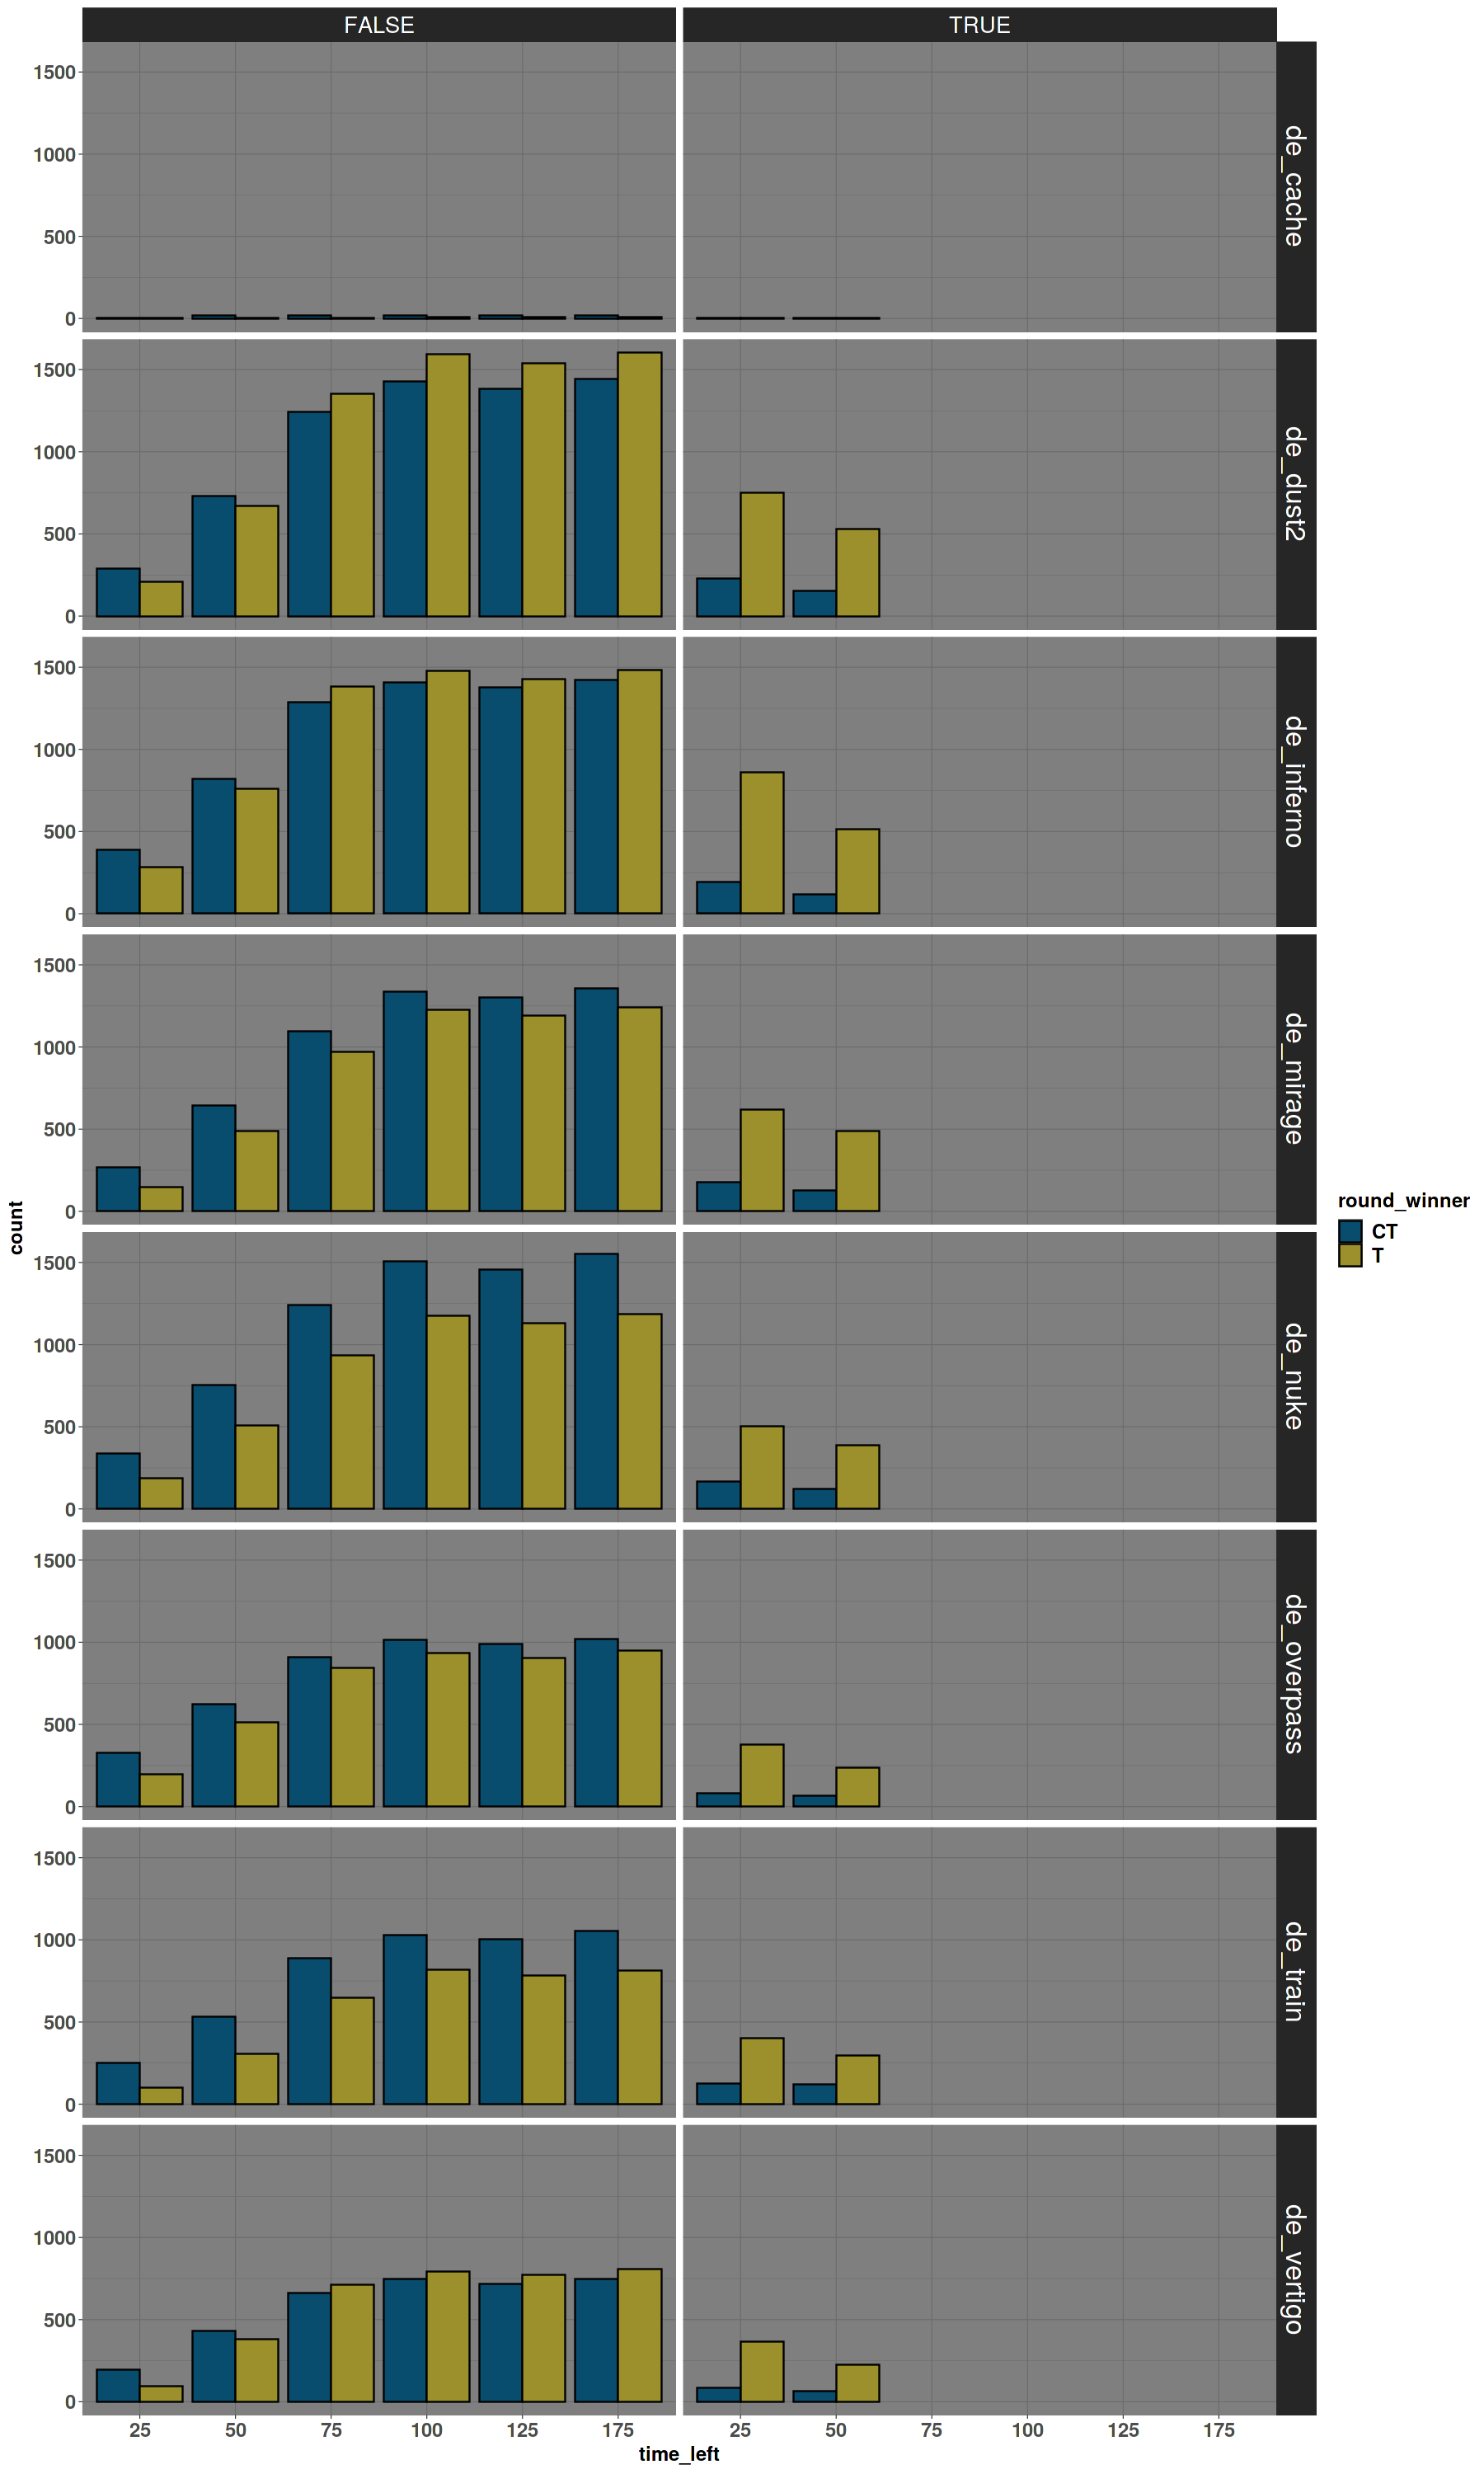

In [19]:
options(repr.plot.height = 25)
dt %>% select(time_left,bomb_planted,round_winner,map) %>%
    mutate(time_left=factor(time_left)) %>%
    ggplot(aes(x=time_left,fill=round_winner))+
    geom_histogram(stat="count",position='dodge',color='black') +
    facet_grid(map~bomb_planted)+
    ctr_fill + 
    theme_dark() +
    theme(axis.text.x = text ,axis.text.y = text,
          axis.title.x = text,axis.title.y = text,
          legend.title = text,legend.text = text,
          plot.title = text,
          strip.text.x = element_text(size = 16, colour = "white"),
          strip.text.y = element_text(size = 20, colour = "white"))

As it can be seen the previously pattern fails to occur in some maps, such as de_dust2, de_inferno and de_vertigo, but only on a small margin. 